<a href="https://colab.research.google.com/github/FarzaadShojaei/movielens-recommender-system/blob/main/recommender_system_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recommendation System Project





```yaml
project_title: "Neural Collaborative Filtering for Movie Recommendation"
dataset_name: "MovieLens 1M"
task_type: "recommender_system"
methods:
  - memory_based_user_cf
  - memory_based_item_cf
  - neural_collaborative_filtering
  - Warm-start neural_collaborative_filtering
  - matrix_factorization_svd

evaluation_metrics:
  - Precision@10
  - Recall@10
  - NDCG@10
  
team_members:
  - name: Melina Mokhtari
    student_id: 947200
    role: Data Explorer / Preprocessing

  - name: Farzad Shojaei
    student_id: 948136
    role:  User-Based CF Implementation  / Experimental Results

  - name: Sogol Shishechiha
    student_id: 948764
    role: Item-Based CF Implementation

  - name: Saeed Sabzeh
    student_id: 947963
    role: Neural CF Model Architecture

  - name: Emanuele Iaconis
    student_id: 881158
    role: Evaluation Methodology / Experimental Results

Submission date: 2026-05-30

```

## AI Usage Declaration

Fill in the following table.

| Item | Response |
|---|---|
| Did you use generative AI tools? | Yes |
| Which tools? | Google Gemini, Grok, Claude AI |
| For what purpose? | brainstorming / coding help / debugging / optimizing code |
| Which parts were AI-assisted? | Data preprocessing logic, NeuCF model architecture, and evaluation functions |
| What did you verify yourself? | Mathematical correctness of metrics, model convergence, and compatibility with MovieLens 1M schema |

### Short declaration
We used Google Gemini, Grok, and Claude AI in our workflow to help with brainstorming the project's structure and cleaning up our PyTorch implementation. These tools were particularly helpful when we were stuck debugging for example complex negative sampling logic or trying to make our evaluation scripts more efficient.

In looping senarios we ran into huge computations on cpu and with help of ai we could reduce complutablity to O(n) or even O(1) for negative sampling.

 Our team manually reviewed every snippet to make sure it actually made sense for the MovieLens 1M dataset. We personally verified all the final metrics and results to ensure everything in this report is accurate and reliable.

## 1. Problem Definition and Motivation

```markdown
## Contribution Metadata
Author(s): ALL 5
Section: 1 — Problem Definition and Motivation
Method: [Top-N Recommendation, Implicit Feedback, Personalized Ranking]
SHORT Description of contribution: Formalized the recommendation task, defined user/item scope, and established the motivation for using neural architectures.
Difficulty: BASIC
```

### Project Statement
This project addresses the challenge of **personalized movie recommendation** at scale. Using the MovieLens 1M dataset, we aim to build a system that can accurately predict and rank movies for users based on their historical preferences (implicit data).

### Task Definition
- **What is being recommended?** Movies from the MovieLens library (~3,900 items).
- **Who are the users?** Over 6,000 anonymous users with diverse viewing histories.
- **What is the items?** Unique films identified by ID and genre metadata.
- **What is the prediction target?** We are solving a **Top-N Recommendation** task. Instead of predicting a specific star rating (1-5), we aim to generate a ranked list of the top 10 movies a user is most likely to interact with.
- **Feedback Type:** We utilize **Implicit Feedback**. We treat high ratings (4 and 5 stars) as positive signals (1) and all other instances as a lack of observed preference (0).

### Motivation and Relevance
Every time we open Netflix or YouTube, recommendation algorithms basically decide what we watch. The problem is that older, simpler models often struggle to understand how messy and complicated human tastes really are.

For this project, we decided to implement Neural Collaborative Filtering (NCF). Instead of just using basic math like dot-products, we wanted to see if a neural network could learn these complex user-item patterns better. Ultimately, our goal is to get the most relevant movies right to the top of the user's list (which we measure using NDCG@10). We specifically chose the MovieLens 1M dataset to see if the neural network could still generate good recommendations even when the data is incredibly sparse and most movies only have a handful of ratings.

## 2. Dataset Description

```markdown
## Contribution Metadata
Author(s): Melina Mokhtari
Section: 2 — Dataset Description
Method: [MovieLens 1M, data schema analysis]
SHORT Description of contribution: Described the MovieLens 1M dataset, including user/item counts and interaction density.
Difficulty: BASIC
```

For this project, we selected the **MovieLens 1M** dataset from GroupLens Research. It is a classic benchmark in recommendation systems, and we specifically chose the 1M version because it gives our neural models a much richer signal to learn from. Originally collected in 2000, it contains about a million interactions from over six thousand users across roughly 3,900 movies.

### Key Statistics
* **Dataset Name:** MovieLens 1M (ml-1m)
* **Users:** 6,040 unique users (everyone in this set has rated at least 20 movies).
* **Items (Movies):** ~3,900 unique titles.
* **Interactions:** 1,000,209 explicit ratings.
* **Density:** ~4.25% (Sparsity: ~95.75%)

### Available Features
Out of the box, the raw dataset provides the following features:
* **Ratings:** Standard explicit feedback on a 1 to 5 scale.
* **Timestamps:** Recorded in Unix seconds since the epoch.
* **User Metadata:** Demographics including gender, age group, occupation, and zip code.
* **Item Metadata:** Movie titles and their associated genres.

### Data Strategy & Filtering
Since we are tackling an **Implicit Feedback** recommendation task, we needed to adapt the raw data. We applied the following cleaning and preprocessing steps:
* **Binarization:** We want our model to learn to recommend movies the user genuinely enjoyed. To do this, we treated 4- and 5-star ratings as 'positive' signals (label 1) and simply ignored the lower ratings.
* **Resulting Subset:** After filtering out the negative interactions and dropping any profiles that became inactive as a result, our final processed dataset consists of exactly 6,038 active users and 575,281 positive interactions.
* **ID Remapping:** To ensure our neural network's embedding lookups run efficiently, we remapped all user and item IDs to contiguous integers `[0, N)`.

## 3. Data Exploration and Preprocessing

```markdown
## Contribution Metadata
Author(s): Melina Mokhtari
Section: 3 — Data Exploration and Preprocessing
Method: [ID remapping, binarization, implicit feedback conversion, temporal splitting]
SHORT Description of contribution: Implemented the cleaning pipeline, filtered high ratings to create implicit signals, remapped IDs for embedding layers, and established a Leave-One-Out evaluation protocol.
Difficulty: INTERMEDIATE
```

Before any model could be trained, the raw MovieLens 1M data needed to be understood and carefully prepared. This section walks through every decision made during exploration and preprocessing — not just what we did, but why each choice made sense for our task.

### 3.1 Exploring the Raw Data
The dataset arrives as three separate files: `ratings.dat`, `users.dat`, and `movies.dat`. The ratings file is the heart of the project — it contains 1,000,209 explicit feedback entries, each recording which user rated which movie, the score they gave (1–5), and when they rated it.

A quick look at the numbers reveals an important structural reality: with 6,040 users and 3,952 movies, the total number of possible user-movie pairs is 23,870,080. Yet only about 1 million of those pairs were ever filled in — giving us a density of just 4.19% and a sparsity of 95.81%. In other words, the vast majority of the matrix is empty. This is a defining challenge of recommendation systems, and it shaped every preprocessing decision that followed.

### 3.2 Converting to Implicit Feedback
Our models are designed around implicit feedback — the idea that a user either interacted with something positively or simply didn't. But the raw data gives us explicit 1–5 star ratings, so we had to make a deliberate filtering choice.

We decided to treat only 4- and 5-star ratings as positive signals (label = 1) and discard everything else. The reasoning is straightforward: a 3-star rating is ambiguous at best, and a 1 or 2 star rating is closer to a negative signal than a positive one. We want the model to learn from genuine interest — not lukewarm engagement. After applying this filter, we were left with 575,281 positive interactions across 6,038 active users.

### 3.3 ID Remapping
The original user and movie IDs in the dataset are not contiguous — there are gaps in the numbering. This becomes a problem when building neural network embedding layers, which expect IDs to map cleanly to row indices in a lookup table.

To fix this, we remapped all user IDs and item IDs to contiguous integers starting from 0. This is a small but essential step — without it, embedding matrices would either be oversized or throw index errors at runtime.

### 3.4 Train / Validation / Test Split (Leave-One-Out)
To evaluate our models in a realistic way, we used a Leave-One-Out protocol based on timestamps. For each user, we sorted their positive interactions chronologically and then:
* **Test Set:** Held out the most recent interaction for testing.
* **Validation Set:** Held out the second most recent interaction for validation (optimization tracking).
* **Training Set:** Used all remaining earlier interactions for training.

In [ ]:
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
import requests
import zipfile
import io
import os

# ====================== Load MovieLens 1M ======================
local_zip_path = "ml-1m.zip"
url = "http://files.grouplens.org/datasets/movielens/ml-1m.zip"

# 1. Check if the zip file is already in the folder
if os.path.exists(local_zip_path):
    print(f"Found local archive at {local_zip_path}. Loading directly...")
    with zipfile.ZipFile(local_zip_path, 'r') as z:
        with z.open('ml-1m/ratings.dat') as f:
            interactions_df = pd.read_csv(f,
                                          sep='::',
                                          engine='python',
                                          names=['user', 'item', 'rating', 'timestamp'],
                                          encoding='latin-1')

# 2. Fallback: Download from web if the archive isn't there
else:
    print("Local archive not found. Downloading from GroupLens...")
    r = requests.get(url)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        with z.open('ml-1m/ratings.dat') as f:
            interactions_df = pd.read_csv(f,
                                          sep='::',
                                          engine='python',
                                          names=['user', 'item', 'rating', 'timestamp'],
                                          encoding='latin-1')
    print("Download and load complete.")



# Turning rating into 1 and 0 for all models
###############################################################################################
#  Filter: Keep only high ratings (4-5) as positive interactions
interactions_df = interactions_df[interactions_df['rating'] >= 4].copy() # makes and hard copy filtered

#  Binarize: Set all ratings to 1 (Implicit signal)
interactions_df['rating'] = 1


# Remap IDs
user2idx = {uid: i for i, uid in enumerate(interactions_df['user'].unique())}
item2idx = {iid: i for i, iid in enumerate(interactions_df['item'].unique())}
interactions_df['user'] = interactions_df['user'].map(user2idx) # substitutes the old IDs with the new indices
interactions_df['item'] = interactions_df['item'].map(item2idx)

num_users = len(user2idx)
num_items = len(item2idx)


Local archive not found. Downloading from GroupLens...
Download and load complete.


In [ ]:
# ====================== Validation Split ======================
from torch.utils.data import TensorDataset, DataLoader

# Sort interactions to extract unique sequence patterns
interactions_df = interactions_df.sort_values(by=['user', 'timestamp']) # orders them first based on the user and
                                                                        # then, for each user it orders the items based
                                                                        # on the timestamp

# 1. Continuous chronological extraction: Leave-One-Out Test Data
test_df = interactions_df.groupby('user').tail(1).copy() # copies the last item for each user (tail(1))
full_train_df = interactions_df.drop(test_df.index).copy() # deletes all the items with the indices corresponding
                                                           # to the items saved in test_df

# 2. Chronological Validation Isolation: Take the second-to-last item for optimization tracking
val_df = full_train_df.groupby('user').tail(1).copy()
train_df = full_train_df.drop(val_df.index).copy()

# Clear out timeline tracking details across active datasets
train_df = train_df.drop(columns=['timestamp'])
val_df = val_df.drop(columns=['timestamp'])
test_df = test_df.drop(columns=['timestamp'])

print(f"Dataset Allocation Status -> Total System Users: {num_users}, Target Items: {num_items}")
print(f"Splits -> Train Count: {len(train_df)} | Validation Count: {len(val_df)} | Test Count: {len(test_df)}")

Dataset Allocation Status -> Total System Users: 6038, Target Items: 3533
Splits -> Train Count: 563206 | Validation Count: 6037 | Test Count: 6038


In [ ]:
# ====================== PyTorch Dataset and DataLoader ======================
class MovieLensDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df['user'].values, dtype=torch.long)
        self.items = torch.tensor(df['item'].values, dtype=torch.long)
        self.ratings = torch.tensor(df['rating'].values, dtype=torch.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

# Create Core Dataloaders
train_loader = DataLoader(MovieLensDataset(train_df), batch_size=1024, shuffle=True)
val_loader = DataLoader(MovieLensDataset(val_df), batch_size=1024, shuffle=False)
test_loader = DataLoader(MovieLensDataset(test_df), batch_size=1024, shuffle=False)

/tmp/ipykernel_95281/1036199128.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=interactions_df, palette='viridis', ax=axes[0])
/tmp/ipykernel_95281/1036199128.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Set', y='Count', data=split_data, palette='magma', ax=axes[1])


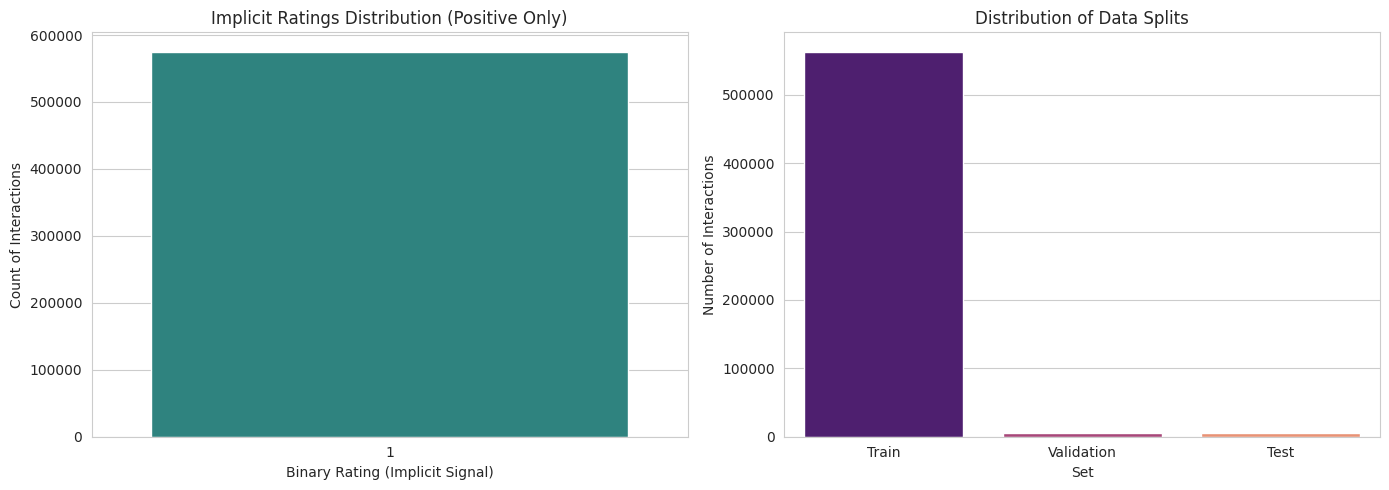

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# --- Visualization ---
fig, axes = plt.subplots(1, 2)

# 1. Distribution of implicit ratings
# Since all ratings are now 1, this shows the count of positive interactions
sns.countplot(x='rating', data=interactions_df, palette='viridis', ax=axes[0])
axes[0].set_title('Implicit Ratings Distribution (Positive Only)') # counts the number of items that have positive rating
axes[0].set_xlabel('Binary Rating (Implicit Signal)')
axes[0].set_ylabel('Count of Interactions')

# 2. Visualization of Data Splits
split_data = pd.DataFrame({
    'Set': ['Train', 'Validation', 'Test'],
    'Count': [len(train_df), len(val_df), len(test_df)]
})

sns.barplot(x='Set', y='Count', data=split_data, palette='magma', ax=axes[1])
axes[1].set_title('Distribution of Data Splits')
axes[1].set_ylabel('Number of Interactions')

plt.tight_layout()
plt.show()

## 4. Baseline Recommender

```markdown
## Contribution Metadata
Author(s):  Farzad Shojaei & Sogol Shishechiha
Section:  Baseline Recommender Systems
Method: [popularity-based filtering, user-based CF, item-based CF, cosine similarity, IDF weighting, Precision@10, Recall@10, NDCG@10]
SHORT Description of contribution:
Implemented Popularity, User-Based CF, and Item-Based CF baselines on data, evaluated using Leave-One-Out with Precision, Recall, and NDCG@10.
Difficulty: INTERMEDIATE
```


## Contribution Metadata
```markdown
Author(s): Farzad Shojaei — Section: 4 — Baseline Recommender
Method: [user-item matrix, popularity, user-based CF, SVD, implicit feedback, top-N recommendation]
SHORT Description of contribution: Built the user-item matrix and implemented three baseline recommenders: Popularity, User-CF, and SVD.
Difficulty: INTERMEDIATE
```


### what we built and why

before throwing a neural network at the problem, we need to know what "simple" looks like. so we implemented three baselines that get progressively smarter, plus the user-item matrix they all depend on.

**user-item matrix** is the starting point — rows are users, columns are movies, 1 if they liked it, 0 otherwise. every baseline model is built on top of this.

**popularity** is the floor. same list for everyone, no personalization. it sounds useless but it's actually important — if our better models can't beat it, something is wrong.

**user-CF** is where actual personalization starts. find users with similar taste, recommend what they liked. it works, but MovieLens is sparse — most users share very few movies in common, so similarity scores get noisy fast.

**SVD** is the strongest linear baseline. instead of working with the sparse matrix directly, it compresses everything into dense latent vectors for users and movies. handles sparsity much better than user-CF and sets a solid ceiling for what a linear model can do before we bring in NeuMF.

### Baseline Recommender

We implemented three baseline recommendation approaches.

The first baseline is a **Popularity-based recommender**. It recommends the most frequently interacted items to all users. This is simple but useful because many real-world systems use popularity as a starting point.

The second baseline is **User-based Collaborative Filtering**. It builds a user-item matrix and computes user similarity using cosine similarity. For each user, the model predicts item scores based on the preferences of similar users.

The third baseline is **Item-Based Collaborative Filtering**. It computes similarity between items based on shared interactions, using IDF weighting to give more importance to niche items over popular ones, then recommends unseen items most similar to what the user already liked.

These baselines help us evaluate whether the proposed neural model provides real improvement over simpler recommendation strategies.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD

np.random.seed(42)

**Cell 3 — User-Item Matrix**

In [ ]:
# -------------------------------------------------
# 3. Build User-Item Matrix
# -------------------------------------------------

user_item_matrix = train_df.pivot_table(
    index="user",
    columns="item",
    values="rating",
    fill_value=0
)

user_item_matrix = user_item_matrix.reindex(
    index=range(num_users),
    columns=range(num_items),
    fill_value=0
)

print("User-item matrix shape:", user_item_matrix.shape)
user_item_matrix.head()

User-item matrix shape: (6038, 3533)


item,0,1,2,3,4,5,6,7,8,9,...,3523,3524,3525,3526,3527,3528,3529,3530,3531,3532
user,,,,,,,,,,,,,,,,,,,,,
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Cell 4 — Popularity Baseline**

In [ ]:
# -------------------------------------------------
# 4. Popularity-based Recommender
# -------------------------------------------------

class PopularityRecommender:
    def __init__(self):
        self.popular_items = None

    def fit(self, train_data):
        item_scores = (
            train_data
            .groupby("item")["rating"]
            .sum()
            .sort_values(ascending=False)
        )

        self.popular_items = item_scores.index.tolist()
        return self

    def recommend(self, user_id, k=10, seen_items=None):
        if seen_items is None:
            seen_items = set()

        recommendations = [
            item for item in self.popular_items
            if item not in seen_items
        ]

        return recommendations[:k]


popularity_model = PopularityRecommender()
popularity_model.fit(train_df)

sample_user = 0
seen_items = set(train_df[train_df["user"] == sample_user]["item"])

print("Popularity-based recommendations for user 0:")
print(popularity_model.recommend(sample_user, k=10, seen_items=seen_items))

Popularity-based recommendations for user 0:
[73, 84, 86, 87, 88, 52, 69, 109, 570, 66]


**Cell 5 — User-based Collaborative Filtering Baseline**

In [ ]:
# -------------------------------------------------
# 5. User-based Collaborative Filtering
# -------------------------------------------------

class UserBasedCF:
    def __init__(self, user_item_matrix):
        self.matrix = user_item_matrix.values.astype(np.float32)  # float32 saves RAM
        self.user_similarity = cosine_similarity(self.matrix)

    def predict_scores(self, user_id):
        sims = self.user_similarity[user_id]
        sim_sum = np.abs(sims).sum()
        if sim_sum == 0:
            return np.zeros(self.matrix.shape[1], dtype=np.float32)
        return np.dot(sims, self.matrix) / sim_sum

    def recommend(self, user_id, k=10, seen_items=None):
        scores = self.predict_scores(user_id).copy()  # copy so we don't mutate cache
        if seen_items:
            valid = [i for i in seen_items if i < len(scores)]
            scores[valid] = -np.inf
        return np.argsort(scores)[::-1][:k].tolist()


user_cf_model = UserBasedCF(user_item_matrix)

sample_user = 0
seen_items = set(train_df[train_df["user"] == sample_user]["item"])
print("User-Based CF recommendations for user 0:")
print(user_cf_model.recommend(sample_user, k=10, seen_items=seen_items))

User-Based CF recommendations for user 0:
[73, 84, 86, 87, 109, 52, 88, 125, 66, 570]





```markdown
Author(s): Sogol Shishechiha — Section: 4 — Item-Based Collaborative Filtering
Method: [item-based collaborative filtering, implicit feedback, IDF weighting, top-N recommendation]
SHORT Description of contribution: Implemented Item-Based CF baseline with IDF weighting for implicit binary feedback data.
Difficulty: INTERMEDIATE
```

### What Is Item-Based Collaborative Filtering?

The intuition is really straightforward: if two movies keep getting liked by the same people, they're probably similar. So if you enjoyed one, you'll likely enjoy the other. The model builds a similarity map across all movies, then for any given user, it looks at what they've watched and uses that map to score everything they haven't seen yet.

### How We Compute Similarity

We use cosine similarity to measure how close two movies are based on who watched them. On top of that we apply IDF weighting — the idea being that if two users both watched an obscure indie film, that says a lot more about their shared taste than both having watched Titanic. Popular movies get down-weighted, niche ones get more credit. Only the top 100 most similar neighbors are kept per movie to avoid noise.

### Why This Fits Our Data

Our dataset uses implicit feedback — there are no star ratings, just a 1 if a user positively interacted with a movie and 0 otherwise. Item-Based CF works naturally here because all it needs to know is who watched what, and the IDF weighting makes sure the similarity signal comes from meaningful shared taste rather than just shared exposure to popular content.

### Evaluation

Like all other baselines in this project, the model is evaluated using Leave-One-Out protocol with Precision@10, Recall@10, and NDCG@10.

**Cell 6 — Item-based Collaborative Filtering Baseline**

In [ ]:
# -------------------------------------------------
# 6. Item-Based Collaborative Filtering
# -------------------------------------------------
class ItemBasedCF:
    def __init__(self, user_item_matrix, n_neighbors=100, min_support=2):
        matrix = user_item_matrix.values.astype(np.float32)
        rated_mask = matrix > 0

        self.matrix      = matrix
        self.rated_mask  = rated_mask.astype(np.float32)
        self.min_support = min_support

        # IDF weighting: down-weight items rated by many users
        n_users     = matrix.shape[0]
        item_counts = rated_mask.sum(axis=0) + 1          # how many users rated each item
        idf         = np.log(n_users / item_counts).astype(np.float32)  # shape: (n_items,)
        weighted    = matrix * idf[np.newaxis, :]          # scale each item column by its IDF

        full_sim = cosine_similarity(weighted.T)
        np.fill_diagonal(full_sim, 0)

        # Keep top-N neighbors
        n_items     = full_sim.shape[0]
        sparse_sim  = np.zeros_like(full_sim, dtype=np.float32)
        top_indices = np.argsort(full_sim, axis=1)[:, -n_neighbors:]
        rows = np.repeat(np.arange(n_items), n_neighbors)
        cols = top_indices.flatten()
        sparse_sim[rows, cols] = full_sim[rows, cols]

        self.sparse_sim = sparse_sim

    def predict_scores_batch(self, user_ids):
        ratings = self.matrix[user_ids]
        scores  = ratings @ self.sparse_sim.T
        weights = self.rated_mask[user_ids] @ self.sparse_sim.T
        scores  = np.where(weights >= self.min_support, scores / np.maximum(weights, 1e-9), 0)
        return scores

    def predict_scores(self, user_id):
        return self.predict_scores_batch(np.array([user_id]))[0]

    def recommend(self, user_id, k=10, seen_items=None):
        scores = self.predict_scores(user_id).copy()
        if seen_items:
            valid = [i for i in seen_items if i < len(scores)]
            scores[valid] = -np.inf
        return np.argsort(scores)[::-1][:k].tolist()

item_cf_model = ItemBasedCF(user_item_matrix, n_neighbors=100, min_support=2)
sample_user = 0
seen_items  = set(train_df[train_df["user"] == sample_user]["item"])
recs        = item_cf_model.recommend(sample_user, k=10, seen_items=seen_items)
print("Item-Based CF recommendations for user 0:")
print(recs)





Item-Based CF recommendations for user 0:
[495, 496, 515, 501, 503, 504, 1560, 523, 334, 511]


**Cell 7 — Representation Learning Baseline with SVD**

In [ ]:

# -------------------------------------------------
# 7. Representation Learning Baseline
#    Matrix Factorization via TruncatedSVD
# -------------------------------------------------
# TruncatedSVD decomposes the user-item matrix R ≈ U · Σ · Vᵀ
# User embeddings  : U · Σ  → shape (users, k)
# Item embeddings  : Vᵀ     → shape (k, items)
# Predicted matrix : U · Σ · Vᵀ → reconstructed ratings

class RepresentationLearningRecommender:
    def __init__(self, n_components=10, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.svd = None
        self.user_embeddings = None   # (users, k)
        self.item_embeddings = None   # (items, k)
        self.predicted_matrix = None  # (users, items)

    def fit(self, user_item_matrix):
        # Guard: TruncatedSVD requires n_components < min(shape)
        safe_k = min(self.n_components, min(user_item_matrix.shape) - 1)

        self.svd = TruncatedSVD(n_components=safe_k, random_state=self.random_state)

        self.user_embeddings = self.svd.fit_transform(user_item_matrix.values)  # (users, k)
        self.item_embeddings = self.svd.components_.T                           # (items, k)
        self.predicted_matrix = self.user_embeddings @ self.svd.components_     # (users, items)
        return self

    def predict_scores(self, user_id):
        return self.predicted_matrix[user_id]  # already computed — O(1) lookup

    def recommend(self, user_id, k=10, seen_items=None):
        scores = self.predict_scores(user_id).copy()
        if seen_items:
            valid = [i for i in seen_items if i < len(scores)]  # vectorized mask
            scores[valid] = -np.inf
        return np.argsort(scores)[::-1][:k].tolist()

    def get_user_embedding(self, user_id):
        return self.user_embeddings[user_id]

    def get_item_embedding(self, item_id):
        return self.item_embeddings[item_id]


# --- Fit ---
representation_model = RepresentationLearningRecommender(n_components=10, random_state=42)
representation_model.fit(user_item_matrix)

# --- Sample output ---
sample_user = 0
seen_items  = set(train_df[train_df["user"] == sample_user]["item"])

print("SVD recommendations for user 0:")
print(representation_model.recommend(sample_user, k=10, seen_items=seen_items))
print(f"\nUser embedding shape : {representation_model.get_user_embedding(0).shape}")
print(f"Item embedding shape : {representation_model.get_item_embedding(0).shape}")

SVD recommendations for user 0:
[109, 87, 84, 226, 86, 138, 52, 125, 110, 89]

User embedding shape : (10,)
Item embedding shape : (10,)


**Cell 8 — Visualize Learned Representations**

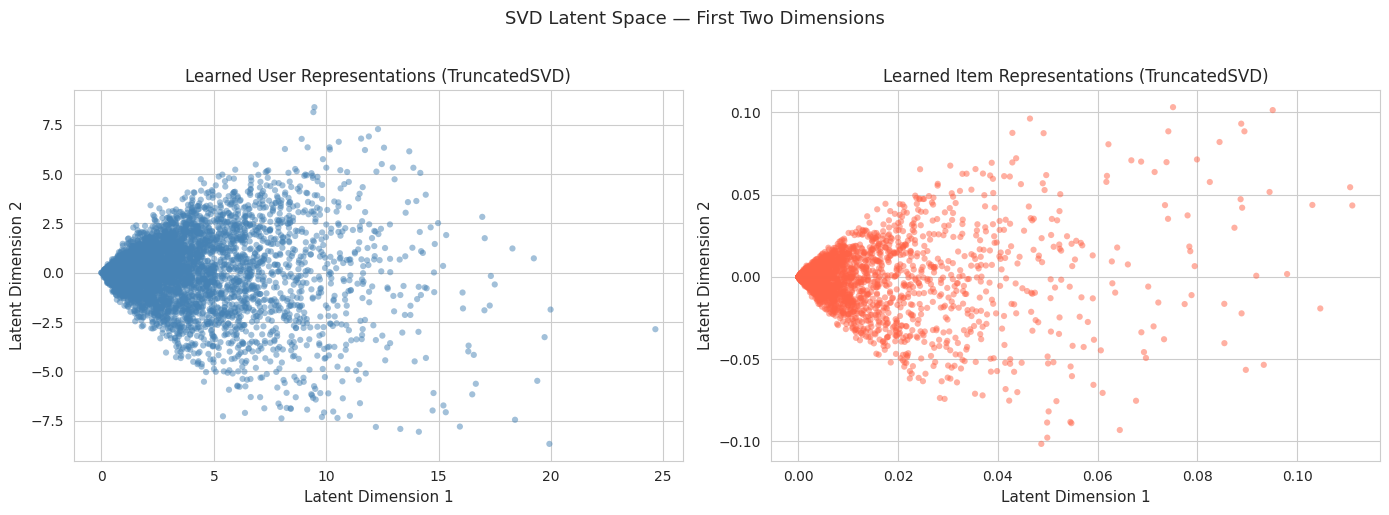

In [ ]:

# -------------------------------------------------
# 8. Visualization of Learned Representations (SVD)
# -------------------------------------------------

user_embeddings = representation_model.user_embeddings  # (users, k)
item_embeddings = representation_model.item_embeddings  # (items, k)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, embeddings, title, color in zip(
    axes,
    [user_embeddings, item_embeddings],
    ["Learned User Representations", "Learned Item Representations"],
    ["steelblue", "tomato"]
):
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        alpha=0.5,
        s=20,
        c=color,
        edgecolors="none"
    )
    ax.set_xlabel("Latent Dimension 1", fontsize=11)
    ax.set_ylabel("Latent Dimension 2", fontsize=11)
    ax.set_title(title + " (TruncatedSVD)", fontsize=12)

plt.suptitle("SVD Latent Space — First Two Dimensions", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Cell 9 — Baseline Evaluation**

In [ ]:
# -------------------------------------------------
# 9. Evaluation: Precision@K, Recall@K, NDCG@K
# -------------------------------------------------

def ndcg_at_k(recommended, relevant, k):
    dcg  = sum(1 / np.log2(rank + 2)
               for rank, item in enumerate(recommended[:k]) if item in relevant)
    idcg = sum(1 / np.log2(rank + 2) for rank in range(min(len(relevant), k)))
    return dcg / idcg if idcg > 0 else 0.0


def evaluate_model(model, train_data, test_data, k=10):
    seen_dict     = train_data.groupby("user")["item"].apply(set).to_dict()
    relevant_dict = test_data.groupby("user")["item"].apply(set).to_dict()

    users = test_data["user"].unique()
    precisions, recalls, ndcgs = [], [], []

    # --- Batch scoring for ItemBasedCF (much faster) ---
    if isinstance(model, ItemBasedCF):
        all_scores = model.predict_scores_batch(users)  # (users, items) in one shot

        for i, user in enumerate(users):
            relevant = relevant_dict.get(user, set())
            if not relevant:
                continue
            seen   = seen_dict.get(user, set())
            scores = all_scores[i].copy()
            if seen:
                valid = [j for j in seen if j < len(scores)]
                scores[valid] = -np.inf
            recommended = np.argsort(scores)[::-1][:k].tolist()

            hits = len(set(recommended) & relevant)
            precisions.append(hits / k)
            recalls.append(hits / len(relevant))
            ndcgs.append(ndcg_at_k(recommended, relevant, k))

    # --- Standard per-user scoring for all other models ---
    else:
        for user in users:
            seen     = seen_dict.get(user, set())
            relevant = relevant_dict.get(user, set())
            if not relevant:
                continue
            recommended = model.recommend(user_id=user, k=k, seen_items=seen)
            hits = len(set(recommended) & relevant)
            precisions.append(hits / k)
            recalls.append(hits / len(relevant))
            ndcgs.append(ndcg_at_k(recommended, relevant, k))

    return {
        f"Precision@{k}": np.mean(precisions),
        f"Recall@{k}"   : np.mean(recalls),
        f"NDCG@{k}"     : np.mean(ndcgs),
    }


K = 10
results = {
    "Popularity" : evaluate_model(popularity_model,     train_df, test_df, k=K),
    "User-CF"    : evaluate_model(user_cf_model,        train_df, test_df, k=K),
    "Item-CF"    : evaluate_model(item_cf_model,        train_df, test_df, k=K),
    "SVD"        : evaluate_model(representation_model, train_df, test_df, k=K),
}

results_df = pd.DataFrame(results).T
results_df.index.name = "Model"

print(f"\n{'='*52}")
print(f"    Baseline Evaluation Summary  (K={K})")
print(f"{'='*52}")
print(results_df.to_string(float_format="{:.4f}".format))


    Baseline Evaluation Summary  (K=10)
            Precision@10  Recall@10  NDCG@10
Model                                       
Popularity        0.0040     0.0402   0.0188
User-CF           0.0049     0.0494   0.0238
Item-CF           0.0024     0.0237   0.0116
SVD               0.0073     0.0732   0.0357


**Cell 10 — Store Results**

In [ ]:
# -------------------------------------------------
# 10. Store Results
# -------------------------------------------------

# Map the existing results from Section 9 to the new naming format without recalculating
baseline_results = {
    "Popularity Baseline"              : results["Popularity"],
    "User-CF Baseline"                 : results["User-CF"],
    "Item-CF Baseline"                 : results["Item-CF"],
    "Representation Learning Baseline" : results["SVD"],
}

baseline_results_df = pd.DataFrame(baseline_results).T
baseline_results_df.index.name = "Model"

**Cell 11 — Baseline Comparsion Bar Chart**


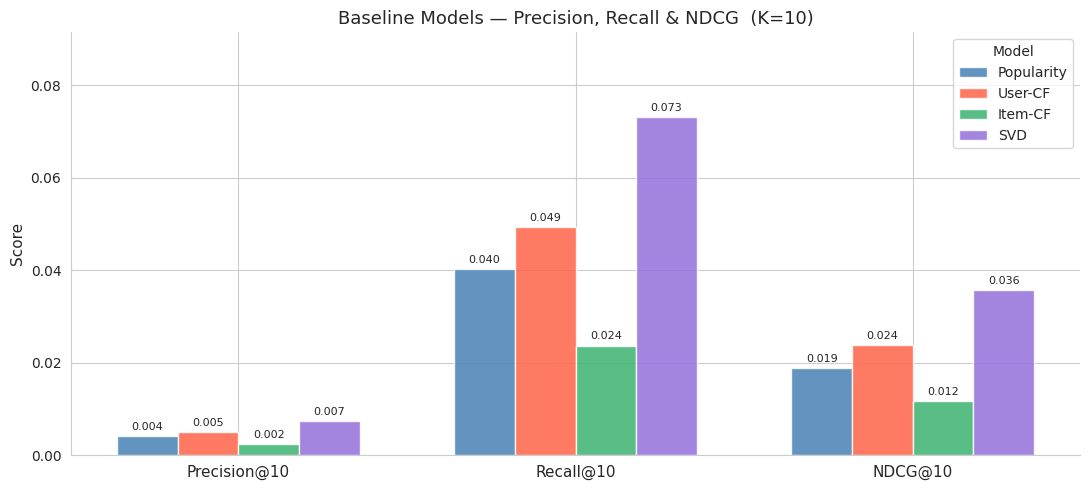

In [ ]:
# -------------------------------------------------
# 11. Baseline Comparison Bar Chart
# -------------------------------------------------

metrics = results_df.columns.tolist()
models  = results_df.index.tolist()
x       = np.arange(len(metrics))
width   = 0.18
colors  = ["steelblue", "tomato", "mediumseagreen", "mediumpurple"]

fig, ax = plt.subplots(figsize=(11, 5))

for i, (model, color) in enumerate(zip(models, colors)):
    vals = results_df.loc[model].values
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title(f"Baseline Models — Precision, Recall & NDCG  (K={K})", fontsize=13)
ax.legend(title="Model", fontsize=10)
ax.set_ylim(0, results_df.values.max() * 1.25)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Proposed Recommendation Model

```markdown
## Contribution Metadata
Author(s):  Saeed Sabzeh
Section:  Recommendation Model - NeuCF
Method: NeuCF + Warm-start NeuCF Using Pytorch
SHORT Description of contribution:
  Built a Neufc Model + A warm start Model involving transfer learning
Difficulty: ADVANCED
```



------------------------

### 1. **Intuition**
Traditional Collaborative Filtering relies on Matrix Factorization (MF), which uses a simple inner product to model user-item interactions. This assumes a linear relationship. Our proposed model, Neural Collaborative Filtering (NCF), is based on the intuition that user-item interactions are complex and non-linear. By replacing the inner product with a neural architecture, we can "learn" the interaction function from the data itself.

### 2. **Design Choices**
We have implemented a NeuMF (Neural Matrix Factorization) architecture, based on paper https://arxiv.org/abs/1708.05031 which is a fusion of two sub-networks:

- Generalized Matrix Factorization (GMF): This branch uses an element-wise product of user and item embeddings to mimic the strengths of standard linear matrix factorization.

- Multi-Layer Perceptron (MLP): This branch concatenates user and item embeddings and passes them through several hidden layers with ReLU activation. This allows the model to capture high-order, non-linear patterns.

- Fusion Layer: The outputs of GMF and MLP are concatenated into a final vector, which is passed through a dense layer with a Sigmoid activation to predict the probability of an interaction.

####important design choices:
We had the chance to have significantly smaller dataset (Movielens 100k) and a significantly smaller model that had much smaller training difficulties, but we decided to go for bigger data to represent more of real situations, and show full capabalities of this model. I believe more data will results in better results from this model compared to baselines.

### 3. **Hyperparameters**
These are picked based on examination on different values.

-   Embedding Size (mf_dim): 128 (for the GMF path).  
-   MLP Layers: [512, 256, 128] (decreasing hidden units to create a "bottleneck" effect).
-   Learning Rate: 0.002 and using schduler to multiply by 0.5 with patient of 5 (using the Adam optimizer for adaptive gradient descent).
-   Batch Size: 256/1024/2048
-   Dropout = 0.2
-   WeightDecay = 2e-5
-   Negative Sampling Ratio: 4:1 or 8:1 or 16:1 (four/eight/... negative instances for every one positive interaction) 16:1 gave the best results.






### 4. Training Procedure
Objective Function: We use Binary Cross-Entropy (BCE) Loss, as the task is treated as a binary classification (interaction vs. no interaction).

- Negative Sampling: Since the dataset only contains positive interactions (ratings), we perform random negative sampling to teach the model to distinguish between items a user likes and items they haven't interacted with.
Negative samples are randomly selected EACH EPOCH.

- Optimizer: Adam optimizer is used to minimize the loss over multiple epochs.

- Validation: We use Rec@10 (as a 1 vs 99) for validating on each epoc

- EarlyStopping: after a certein patient, we determinate training if no progress on validation loss occurs and save the best model.

(We implemented another way of training which involves transfer learning andpre-training. Details are after base model.)

### 5. Why this model is appropriate
The MovieLens 1M dataset contains sparse interaction data. A standard SVD baseline (as seen in Section 4) might fail to capture the nuanced preferences of users. The NeuMF model is appropriate because it provides the best of both worlds: the linearity of GMF and the non-linearity of MLP, leading to better ranking performance (Precision and Recall) than simple baselines.
As seen in paper, this is more generilized (contains) the matrix factorilization.


### Use of AI:
AI(google gemini) has been used to improve the code computationaly and debugging.

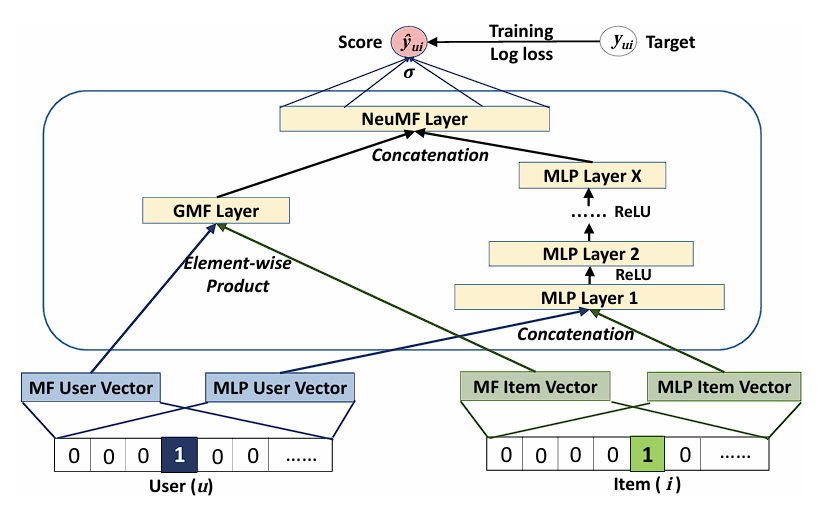

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import os

In [ ]:
 # These evaluations were used in trainig, validating, etc

def evaluate_ncf_model(model, train_data, test_data, num_items, k=10):

    #Standard NCF 1-vs-99 Evaluation Protocol USED FOR TRAINIG
    #Calculates Mean Precision@K and Recall@K (Hit Ratio@K)

    model.eval()
    device = next(model.parameters()).device

    hits = 0
    users = test_data["user"].unique()

    # Pre-compute seen items to avoid O(N^2) Pandas filtering in the loop
    seen_items_dict = train_data.groupby('user')['item'].apply(set).to_dict()

    with torch.no_grad(): #NOT SAVING GRADIENT JUST CHECKING AND NOT LEARNING
        for user in users:
            # Get the single held-out test item for this user
            test_item = test_data[test_data["user"] == user]["item"].iloc[0]
            seen_items = seen_items_dict.get(user, set())

            # Sample 99 negative items the user has never interacted with
            negatives = []
            while len(negatives) < 99:
                neg = np.random.randint(0, num_items)
                if neg not in seen_items and neg != test_item:
                    negatives.append(neg)

            # Combine the 1 positive and 99 negatives
            items_to_rank = [test_item] + negatives

            user_tensor = torch.tensor([user] * 100, dtype=torch.long).to(device)
            item_tensor = torch.tensor(items_to_rank, dtype=torch.long).to(device)

            # Get predictions for these 100 items
            predictions = model(user_tensor, item_tensor).cpu().numpy()

            # Get the indices of the top K recommended items
            top_k_indices = np.argsort(predictions)[-k:][::-1]

            # The true test item is always at index 0. If 0 is in the top K, its a hit
            if 0 in top_k_indices:
                hits += 1

    # In LOO, Mean Recall is Hit Ratio.
    # Mean Precision is Hit Ratio divided by K.
    hit_ratio = hits / len(users)

    return hit_ratio / k, hit_ratio



def evaluate_ncf_model_for_eval(model, train_data, test_data, num_items, k=10):

    ## #NCF Evaluation Logic
    ### Calculates Mean Precision@K and Recall@K

    model.eval() #TURNS OFF DROPOUT
    device = next(model.parameters()).device

    precisions = []
    recalls = []

    users = test_data["user"].unique()
    all_items_tensor = torch.arange(num_items, dtype=torch.long).to(device)

    with torch.no_grad():
        for user in users:
            seen_items = set(train_data[train_data["user"] == user]["item"])
            relevant_items = set(test_data[test_data["user"] == user]["item"])

            if len(relevant_items) == 0:
                continue

            user_tensor = torch.tensor([user] * num_items, dtype=torch.long).to(device)

            # Get predictions for all items
            predictions = model(user_tensor, all_items_tensor).cpu().numpy()

            # Mask items seen in training
            if seen_items:
                # Ensure indices are within bounds of the prediction array
                valid_seen = [i for i in seen_items if i < len(predictions)]
                predictions[valid_seen] = -np.inf

            # Get the top K recommended item indices
            recommended_items = set(np.argsort(predictions)[-k:][::-1])

            # Calculate hits
            hits = len(recommended_items & relevant_items)

            precisions.append(hits / k)
            recalls.append(hits / len(relevant_items))

    return np.mean(precisions), np.mean(recalls)

def evaluate_ncf_proposed_model(model, train_data, test_data, num_items, k=10):

    ###Detailed NCF Evaluation Logic
    ###Calculates Mean Precision@K, Recall@K, and NDCG@K

    model.eval()
    device = next(model.parameters()).device

    precisions, recalls, ndcgs = [], [], []
    users = test_data["user"].unique()
    all_items_tensor = torch.arange(num_items, dtype=torch.long).to(device)

    seen_dict = train_data.groupby("user")["item"].apply(set).to_dict()
    relevant_dict = test_data.groupby("user")["item"].apply(set).to_dict()

    with torch.no_grad():
        for user in users:
            seen = seen_dict.get(user, set())
            relevant = relevant_dict.get(user, set())
            if not relevant:
                continue

            user_tensor = torch.tensor([user] * num_items, dtype=torch.long).to(device)
            predictions = model(user_tensor, all_items_tensor).cpu().numpy()

            if seen:
                valid_seen = [i for i in seen if i < len(predictions)]
                predictions[valid_seen] = -np.inf

            recommended = np.argsort(predictions)[-k:][::-1]

            # Metric: NDCG
            dcg = sum(1 / np.log2(rank + 2) for rank, item in enumerate(recommended) if item in relevant)
            idcg = sum(1 / np.log2(rank + 2) for rank in range(min(len(relevant), k)))

            # Metric: Precision/Recall
            hits = len(set(recommended) & relevant)

            precisions.append(hits / k)
            recalls.append(hits / len(relevant))
            ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return np.mean(precisions), np.mean(recalls), np.mean(ndcgs)


In [ ]:

#NCF


import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class NCFDataset(Dataset):
    def __init__(self, df, num_items, num_negatives=16): #  NCF traditionally uses 4
        # Convert to numpy arrays for fast PyTorch indexing
        self.users = df['user'].values
        self.items = df['item'].values
        self.labels = np.ones(len(self.users), dtype=np.float32)
        self.num_items = num_items
        self.num_negatives = num_negatives

        # Pre-compute seen items per user as a dictionary of sets for O(1) lookups.
        # This is massively faster than checking a giant set of (user, item) tuples. used in neg sampling
        self.user_seen_dict = df.groupby('user')['item'].apply(set).to_dict()

        # Initialize placeholders for negatives
        self.neg_users = np.array([], dtype=np.int64)
        self.neg_items = np.array([], dtype=np.int64)
        self.neg_labels = np.array([], dtype=np.float32)

    def sample_negatives(self):
        """Vectorized negative sampling to eliminate CPU bottlenecks.by AI"""
        num_positives = len(self.users) # len(self.users) gives all the positives
        num_neg_samples = num_positives * self.num_negatives

        # generate negative users by repeating the positive users array
        neg_users = np.repeat(self.users, self.num_negatives)

        # 2. Bulk generate random items instantly using NumPy
        neg_items = np.random.randint(0, self.num_items, size=num_neg_samples)

        # 3. Fix collisions (the rare cases where a random item is a positive item)
        # Because the matrix is >95% sparse, this while loop almost never triggers.
        for i in range(num_neg_samples):
            u = neg_users[i]
            j = neg_items[i]

            # If collision occurs, resample just that single item
            while j in self.user_seen_dict[u]:
                j = np.random.randint(0, self.num_items)
                neg_items[i] = j

        # Store the generated negatives
        self.neg_users = neg_users
        self.neg_items = neg_items
        self.neg_labels = np.zeros(num_neg_samples, dtype=np.float32)


    def __len__(self):
        # Total length is positive interactions + negative samples
        return len(self.users) + len(self.neg_users)

    def __getitem__(self, idx):
        # Return positive samples first, then negative samples
        if idx < len(self.users):
            return self.users[idx], self.items[idx], self.labels[idx]
        else:
            neg_idx = idx - len(self.users) #IF we returned all positives, start returning negatives.
            return self.neg_users[neg_idx], self.neg_items[neg_idx], self.neg_labels[neg_idx]

# 2. Model Class (The actual Neural Network)
class NCFModel(nn.Module):
    def __init__(self, num_users, num_items):
        super(NCFModel, self).__init__()
        # Large Embeddings
        self.embed_user_GMF = nn.Embedding(num_users, 128)
        self.embed_item_GMF = nn.Embedding(num_items, 128)
        self.embed_user_MLP = nn.Embedding(num_users, 256)
        self.embed_item_MLP = nn.Embedding(num_items, 256)

        # Small/Bottlenecked MLP
        self.mlp_layers = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
        )

        self.prediction = nn.Linear( 256, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, u, i):
        phi_gmf = self.embed_user_GMF(u) * self.embed_item_GMF(i)
        phi_mlp = self.mlp_layers(torch.cat([self.embed_user_MLP(u), self.embed_item_MLP(i)], dim=-1))
        return self.sigmoid(self.prediction(torch.cat([phi_gmf, phi_mlp], dim=-1))).view(-1)


In [ ]:
class EarlyStopping:
    def __init__(self, patience=2, verbose=False, delta=0, path='best_model.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        # FIX: Changed strictly less than (<) to less than or equal to (<=)
        elif score <= self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [ ]:

# Training Loop INITIALIZING

# Use the device (T4 GPU IN COLAB)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Use the recalculated counts for the real MovieLens data
num_users_real = interactions_df['user'].max() + 1
num_items_real = interactions_df['item'].max() + 1

# Initialize model and dataset
model = NCFModel(num_users, num_items).to(device)
dataset = NCFDataset(train_df, num_items)
optimizer = optim.Adam(model.parameters(), lr=0.002, weight_decay=2e-5)
criterion = nn.BCELoss()
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Configuration of Training
patience = 10
counter = 0
best_recall = -float('inf')
best_model_state = None


early_stopping = EarlyStopping(patience=patience, verbose=True, path='best_model.pt')

In [ ]:
import gdown
import torch
# To 'load' or 'not to load'. that's the question!
def ask_and_load_model(model, model_type, device):
    """
    model_type:
    'base' -> Base NCF
    'warm' -> Warm Start NCF
    """
    model_links = {
        "base": {
            "id": "1nK0wY31e0WCTT5C531onc98sT_OrA8q1", #google drive link
            "file": "base_ncf_model.pth"
        },
        "warm": {
            "id": "1T62tc847IEBMyKMpgeIGMTEu-24Pe3hf",
            "file": "warm_start_model.pth"
        }
    }

    choice = input(f"Load pretrained {model_type} model? (y/n): ").lower()

    if choice != "y":
        print("Training from scratch...\n")
        return False

    model_info = model_links[model_type]
    file_id = model_info["id"]
    save_path = model_info["file"]

    if not os.path.exists(save_path):
        print(f"Downloading pretrained {model_type} model...")
        gdown.download(id=file_id, output=save_path, quiet=False)

    print("Loading weights...")
    model.load_state_dict(torch.load(save_path, map_location=device))
    model.to(device)
    print(f"Pretrained {model_type} model loaded successfully.\n")
    return True

In [ ]:
import os
import torch
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# Training


model.to(device)


# 1. Choice to Load or Train
loaded = ask_and_load_model(model, "base", device)

# 2. Training Block
if not loaded:
    print("Starting training from scratch...")
    dataset = NCFDataset(train_df, num_items) #Same training dataframe as other baselines
    train_loader = DataLoader(dataset, batch_size=2048, shuffle=True, pin_memory=True)

    for epoch in range(50):
        model.train()
        dataset.sample_negatives()

        total_train_loss = 0
        for u, i, l in train_loader:
            u, i, l = u.to(device), i.to(device), l.float().to(device)

            optimizer.zero_grad()
            prediction = model(u, i)
            loss = criterion(prediction, l)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        val_precision, val_recall = evaluate_ncf_model(
            model, train_df, val_df, num_items=num_items, k=10
        )

        val_metric = 1 - val_recall
        scheduler.step(val_metric)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Epoch {epoch+1:03d} | LR: {current_lr:.6e} | Loss: {avg_train_loss:.4f} | "
              f"Prec@10: {val_precision:.4f} | Rec@10: {val_recall:.4f}")

        # Saves checkpoint during training
        early_stopping(val_metric, model)

        if early_stopping.early_stop or current_lr < 1e-6:
            print("Stopping criteria met.")
            break

# 3. Finalize: Only load local checkpoint if training ran
if not loaded:
    checkpoint_path = early_stopping.path if hasattr(early_stopping, 'path') else 'best_model.pt'
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device))
        print("Best trained model weights successfully loaded.")
else:
    print("Pretrained base model weights are active and ready for evaluation.")

# 4. just a simple Evaluation
test_precision, test_recall = evaluate_ncf_model(
    model, train_df, test_df, num_items=num_items, k=10
)
print(f"Final Test Performance -> Prec@10: {test_precision:.4f} | Rec@10: {test_recall:.4f}")

Load pretrained base model? (y/n): y
Loading weights...
Pretrained base model loaded successfully.

Pretrained base model weights are active and ready for evaluation.
Final Test Performance -> Prec@10: 0.0669 | Rec@10: 0.6686


last training logs:
EXECUTED IN 51 Minutes.


```markdown
Load pretrained base model? (y/n): n
Training from scratch...

Starting training from scratch...
Epoch 001 | LR: 2.000000e-03 | Loss: 0.1707 | Prec@10: 0.0485 | Rec@10: 0.4852
Validation loss decreased (inf --> 0.514825). Saving model...
Epoch 002 | LR: 2.000000e-03 | Loss: 0.1630 | Prec@10: 0.0513 | Rec@10: 0.5125
Validation loss decreased (0.514825 --> 0.487494). Saving model...
Epoch 003 | LR: 2.000000e-03 | Loss: 0.1547 | Prec@10: 0.0539 | Rec@10: 0.5390
Validation loss decreased (0.487494 --> 0.460991). Saving model...
Epoch 004 | LR: 2.000000e-03 | Loss: 0.1504 | Prec@10: 0.0572 | Rec@10: 0.5723
Validation loss decreased (0.460991 --> 0.427696). Saving model...
Epoch 005 | LR: 2.000000e-03 | Loss: 0.1460 | Prec@10: 0.0595 | Rec@10: 0.5945
Validation loss decreased (0.427696 --> 0.405499). Saving model...
Epoch 006 | LR: 2.000000e-03 | Loss: 0.1430 | Prec@10: 0.0611 | Rec@10: 0.6106
Validation loss decreased (0.405499 --> 0.389432). Saving model...
Epoch 007 | LR: 2.000000e-03 | Loss: 0.1415 | Prec@10: 0.0619 | Rec@10: 0.6187
Validation loss decreased (0.389432 --> 0.381315). Saving model...
Epoch 008 | LR: 2.000000e-03 | Loss: 0.1405 | Prec@10: 0.0622 | Rec@10: 0.6225
Validation loss decreased (0.381315 --> 0.377505). Saving model...
Epoch 009 | LR: 2.000000e-03 | Loss: 0.1397 | Prec@10: 0.0630 | Rec@10: 0.6301
Validation loss decreased (0.377505 --> 0.369886). Saving model...
Epoch 010 | LR: 2.000000e-03 | Loss: 0.1392 | Prec@10: 0.0619 | Rec@10: 0.6190
EarlyStopping counter: 1 out of 10
Epoch 011 | LR: 2.000000e-03 | Loss: 0.1388 | Prec@10: 0.0630 | Rec@10: 0.6296
EarlyStopping counter: 2 out of 10
Epoch 012 | LR: 2.000000e-03 | Loss: 0.1384 | Prec@10: 0.0639 | Rec@10: 0.6391
Validation loss decreased (0.369886 --> 0.360941). Saving model...
Epoch 013 | LR: 2.000000e-03 | Loss: 0.1383 | Prec@10: 0.0629 | Rec@10: 0.6290
EarlyStopping counter: 1 out of 10
Epoch 014 | LR: 2.000000e-03 | Loss: 0.1382 | Prec@10: 0.0628 | Rec@10: 0.6278
EarlyStopping counter: 2 out of 10
Epoch 015 | LR: 2.000000e-03 | Loss: 0.1380 | Prec@10: 0.0634 | Rec@10: 0.6343
EarlyStopping counter: 3 out of 10
Epoch 016 | LR: 2.000000e-03 | Loss: 0.1380 | Prec@10: 0.0640 | Rec@10: 0.6404
Validation loss decreased (0.360941 --> 0.359616). Saving model...
Epoch 017 | LR: 2.000000e-03 | Loss: 0.1380 | Prec@10: 0.0635 | Rec@10: 0.6348
EarlyStopping counter: 1 out of 10
Epoch 018 | LR: 2.000000e-03 | Loss: 0.1380 | Prec@10: 0.0634 | Rec@10: 0.6341
EarlyStopping counter: 2 out of 10
Epoch 019 | LR: 2.000000e-03 | Loss: 0.1378 | Prec@10: 0.0632 | Rec@10: 0.6321
EarlyStopping counter: 3 out of 10
Epoch 020 | LR: 1.000000e-03 | Loss: 0.1379 | Prec@10: 0.0632 | Rec@10: 0.6323
EarlyStopping counter: 4 out of 10
Epoch 021 | LR: 1.000000e-03 | Loss: 0.1326 | Prec@10: 0.0667 | Rec@10: 0.6672
Validation loss decreased (0.359616 --> 0.332781). Saving model...
Epoch 022 | LR: 1.000000e-03 | Loss: 0.1317 | Prec@10: 0.0670 | Rec@10: 0.6704
Validation loss decreased (0.332781 --> 0.329634). Saving model...
Epoch 023 | LR: 1.000000e-03 | Loss: 0.1316 | Prec@10: 0.0677 | Rec@10: 0.6770
Validation loss decreased (0.329634 --> 0.323008). Saving model...
Epoch 024 | LR: 1.000000e-03 | Loss: 0.1316 | Prec@10: 0.0668 | Rec@10: 0.6684
EarlyStopping counter: 1 out of 10
Epoch 025 | LR: 1.000000e-03 | Loss: 0.1315 | Prec@10: 0.0671 | Rec@10: 0.6705
EarlyStopping counter: 2 out of 10
Epoch 026 | LR: 1.000000e-03 | Loss: 0.1313 | Prec@10: 0.0672 | Rec@10: 0.6715
EarlyStopping counter: 3 out of 10
Epoch 027 | LR: 5.000000e-04 | Loss: 0.1312 | Prec@10: 0.0671 | Rec@10: 0.6714
EarlyStopping counter: 4 out of 10
Epoch 028 | LR: 5.000000e-04 | Loss: 0.1271 | Prec@10: 0.0699 | Rec@10: 0.6985
Validation loss decreased (0.323008 --> 0.301474). Saving model...
Epoch 029 | LR: 5.000000e-04 | Loss: 0.1262 | Prec@10: 0.0703 | Rec@10: 0.7033
Validation loss decreased (0.301474 --> 0.296671). Saving model...
Epoch 030 | LR: 5.000000e-04 | Loss: 0.1258 | Prec@10: 0.0697 | Rec@10: 0.6972
EarlyStopping counter: 1 out of 10
Epoch 031 | LR: 5.000000e-04 | Loss: 0.1255 | Prec@10: 0.0700 | Rec@10: 0.7003
EarlyStopping counter: 2 out of 10
Epoch 032 | LR: 5.000000e-04 | Loss: 0.1251 | Prec@10: 0.0701 | Rec@10: 0.7012
EarlyStopping counter: 3 out of 10
Epoch 033 | LR: 2.500000e-04 | Loss: 0.1246 | Prec@10: 0.0702 | Rec@10: 0.7018
EarlyStopping counter: 4 out of 10
Epoch 034 | LR: 2.500000e-04 | Loss: 0.1209 | Prec@10: 0.0706 | Rec@10: 0.7063
Validation loss decreased (0.296671 --> 0.293689). Saving model...
Epoch 035 | LR: 2.500000e-04 | Loss: 0.1194 | Prec@10: 0.0717 | Rec@10: 0.7166
Validation loss decreased (0.293689 --> 0.283419). Saving model...
Epoch 036 | LR: 2.500000e-04 | Loss: 0.1185 | Prec@10: 0.0718 | Rec@10: 0.7179
Validation loss decreased (0.283419 --> 0.282094). Saving model...
Epoch 037 | LR: 2.500000e-04 | Loss: 0.1177 | Prec@10: 0.0717 | Rec@10: 0.7174
EarlyStopping counter: 1 out of 10
Epoch 038 | LR: 2.500000e-04 | Loss: 0.1170 | Prec@10: 0.0724 | Rec@10: 0.7235
Validation loss decreased (0.282094 --> 0.276462). Saving model...
Epoch 039 | LR: 2.500000e-04 | Loss: 0.1162 | Prec@10: 0.0717 | Rec@10: 0.7174
EarlyStopping counter: 1 out of 10
Epoch 040 | LR: 2.500000e-04 | Loss: 0.1155 | Prec@10: 0.0720 | Rec@10: 0.7199
EarlyStopping counter: 2 out of 10
Epoch 041 | LR: 2.500000e-04 | Loss: 0.1148 | Prec@10: 0.0726 | Rec@10: 0.7255
Validation loss decreased (0.276462 --> 0.274474). Saving model...
Epoch 042 | LR: 2.500000e-04 | Loss: 0.1141 | Prec@10: 0.0723 | Rec@10: 0.7230
EarlyStopping counter: 1 out of 10
Epoch 043 | LR: 2.500000e-04 | Loss: 0.1134 | Prec@10: 0.0718 | Rec@10: 0.7184
EarlyStopping counter: 2 out of 10
Epoch 044 | LR: 2.500000e-04 | Loss: 0.1128 | Prec@10: 0.0723 | Rec@10: 0.7230
EarlyStopping counter: 3 out of 10
Epoch 045 | LR: 1.250000e-04 | Loss: 0.1122 | Prec@10: 0.0724 | Rec@10: 0.7235
EarlyStopping counter: 4 out of 10
Epoch 046 | LR: 1.250000e-04 | Loss: 0.1078 | Prec@10: 0.0729 | Rec@10: 0.7292
Validation loss decreased (0.274474 --> 0.270830). Saving model...
Epoch 047 | LR: 1.250000e-04 | Loss: 0.1061 | Prec@10: 0.0732 | Rec@10: 0.7322
Validation loss decreased (0.270830 --> 0.267848). Saving model...
Epoch 048 | LR: 1.250000e-04 | Loss: 0.1049 | Prec@10: 0.0728 | Rec@10: 0.7280
EarlyStopping counter: 1 out of 10
Epoch 049 | LR: 1.250000e-04 | Loss: 0.1041 | Prec@10: 0.0729 | Rec@10: 0.7285
EarlyStopping counter: 2 out of 10
Epoch 050 | LR: 1.250000e-04 | Loss: 0.1034 | Prec@10: 0.0729 | Rec@10: 0.7290
EarlyStopping counter: 3 out of 10
Best trained model weights successfully loaded.
Final Test Performance -> Prec@10: 0.0691 | Rec@10: 0.6915
```

In [ ]:
model

NCFModel(
  (embed_user_GMF): Embedding(6038, 128)
  (embed_item_GMF): Embedding(3533, 128)
  (embed_user_MLP): Embedding(6038, 256)
  (embed_item_MLP): Embedding(3533, 256)
  (mlp_layers): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
  )
  (prediction): Linear(in_features=256, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

# DIFFERENT TRAINING
We developed an other model with a different approch to training procedure. In this model, we first pre-trained GMF and MLP parts seperatly, then passed the parameters into a complete NeuCF model. After fusing these two parts, we have a phase to train only the head of the model, then we have a fine-tuning of the whole model. Although expected to give better result as a warm-start model, its benchmark shows only little improvement.

This trining is the offical approch in the mentioned paper.

(Models are same size.)

##Base NeuCF Training (From Scratch)

Single-Phase: The model is trained entirely end-to-end in one go.

Initialization: Both the GMF (Generalized Matrix Factorization) and MLP (Multi-Layer Perceptron) branches are initialized with random weights.

Execution: The entire fused network learns simultaneously over 50 epochs using an Adam optimizer and a learning rate scheduler.

##Warm-Start NeuCF Training (Transfer Learning)

Multi-Phase: The training is split into four distinct steps to pre-train components before fusing them.

Step 1 (Pre-train GMF): A standalone GMF model is trained separately for 25 epochs.

Step 2 (Pre-train MLP): A standalone MLP model is trained separately for 25 epochs.

Step 3 (Fusion): The learned weights from both pre-trained models are transferred into the complete NeuCF model, providing a "warm" structured starting point instead of random noise.

Step 4 (Fine-Tuning): All layers are unfrozen, and the entire combined model is fine-tuned at a lower learning rate for 20 epochs.


(Early stopping is used in all the trainings)

#Transfer Learning




In [ ]:
# TRANSFER LEARNING MODELS


import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader
import os

#  MODELS

class GMF(nn.Module):
    def __init__(self, num_users, num_items, mf_dim=128):
        super(GMF, self).__init__()
        self.embed_user = nn.Embedding(num_users, mf_dim)
        self.embed_item = nn.Embedding(num_items, mf_dim)
        self.prediction = nn.Linear(mf_dim, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

        nn.init.normal_(self.embed_user.weight, std=0.01)
        nn.init.normal_(self.embed_item.weight, std=0.01)

        # Add this line to act as a pure dot-product initially
        nn.init.constant_(self.prediction.weight, 1.0)

    def forward(self, user, item):
        interaction = self.embed_user(user) * self.embed_item(item)
        return self.sigmoid(self.prediction(interaction)).view(-1)

class MLPStandalone(nn.Module):
    def __init__(self, num_users, num_items):
        super(MLPStandalone, self).__init__()
        self.embed_user = nn.Embedding(num_users, 256)
        self.embed_item = nn.Embedding(num_items, 256)
        self.linear1 = nn.Linear(512, 256)
        self.linear2 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.1)
        self.pred = nn.Linear(128, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, user_indices, item_indices):
        user_embed = self.embed_user(user_indices)
        item_embed = self.embed_item(item_indices)
        x = torch.cat([user_embed, item_embed], dim=-1)
        x = self.dropout(torch.relu(self.linear1(x)))
        x = self.dropout(torch.relu(self.linear2(x)))
        return self.sigmoid(self.pred(x)).view(-1)




class NeuMF_Pretrained(nn.Module):
    def __init__(self, num_users, num_items):
        super(NeuMF_Pretrained, self).__init__()
        self.embed_user_GMF = nn.Embedding(num_users, 128)
        self.embed_item_GMF = nn.Embedding(num_items, 128)
        self.embed_user_MLP = nn.Embedding(num_users, 256)
        self.embed_item_MLP = nn.Embedding(num_items, 256)
        self.linear1 = nn.Linear(512, 256)
        self.linear2 = nn.Linear(256, 128)
        self.dropout = nn.Dropout(0.1)
        self.pred = nn.Linear(128 + 128, 1, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, user, item):
        gmf = self.embed_user_GMF(user) * self.embed_item_GMF(item)
        mlp_x = torch.cat([self.embed_user_MLP(user), self.embed_item_MLP(item)], dim=-1)
        mlp_x = self.dropout(torch.relu(self.linear1(mlp_x)))
        mlp_x = self.dropout(torch.relu(self.linear2(mlp_x)))
        fused = torch.cat([gmf, mlp_x], dim=-1)
        return self.sigmoid(self.pred(fused)).view(-1)

    def load_pretrained(self, gmf_model, mlp_model, alpha=0.5):
        # 1. Transfer Embeddings
        self.embed_user_GMF.weight.data.copy_(gmf_model.embed_user.weight.data)
        self.embed_item_GMF.weight.data.copy_(gmf_model.embed_item.weight.data)
        self.embed_user_MLP.weight.data.copy_(mlp_model.embed_user.weight.data)
        self.embed_item_MLP.weight.data.copy_(mlp_model.embed_item.weight.data)

        # 2. Transfer MLP Hidden Layers
        self.linear1.weight.data.copy_(mlp_model.linear1.weight.data)
        self.linear1.bias.data.copy_(mlp_model.linear1.bias.data)
        self.linear2.weight.data.copy_(mlp_model.linear2.weight.data)
        self.linear2.bias.data.copy_(mlp_model.linear2.bias.data)

        # 3. Fuse the Prediction Heads
        gmf_weight = gmf_model.prediction.weight.data
        mlp_weight = mlp_model.pred.weight.data

        # Concatenate weights along the feature dimension (dim=1)
        fused_weight = torch.cat([alpha * gmf_weight, (1.0 - alpha) * mlp_weight], dim=1)
        self.pred.weight.data.copy_(fused_weight)

    def freeze_embeddings(self, freeze=True):
        layers = [self.embed_user_GMF, self.embed_item_GMF, self.embed_user_MLP,
                  self.embed_item_MLP, self.linear1, self.linear2]
        for layer in layers:
            for p in layer.parameters():
                p.requires_grad = not freeze




In [ ]:
class EarlyStopping:
    def __init__(self, patience=3, verbose=True, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score <= self.best_score:
            self.counter += 1
            if self.verbose: print(f'EarlyStopping: {self.counter}/{self.patience}')
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss


In [ ]:

# TRAINING implementations

def train_transfer_phase(model, base_dataset, train_df, val_df, num_items, epochs, lr, phase_name, batch_size=1024):
    device = next(model.parameters()).device
    criterion = nn.BCELoss()
    # Corrected weight decay and higher LR to force learning
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-5)

    early_stopping = EarlyStopping(patience=3, path=f'best_{phase_name}.pt')

    for epoch in range(epochs):
        model.train()
        base_dataset.sample_negatives()
        loader = DataLoader(base_dataset, batch_size=batch_size, shuffle=True)

        total_loss = 0
        for u, i, l in loader:
            u, i, l = u.to(device), i.to(device), l.float().to(device)
            optimizer.zero_grad()
            pred = model(u, i)
            loss = criterion(pred, l)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        # Evaluation (Invert HR because EarlyStopping tracks losses)
        _, hr = evaluate_ncf_model(model, train_df, val_df, num_items, k=10)
        print(f"[{phase_name}] Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f} | HR@10: {hr:.4f}")

        early_stopping(1.0 - hr, model)
        if early_stopping.early_stop: break

    model.load_state_dict(torch.load(early_stopping.path))
    return model

In [ ]:
# Training EXECUTION

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_warm = NeuMF_Pretrained(num_users, num_items).to(device)

loaded = ask_and_load_model(model_warm, "warm", device)

if not loaded:
    print("Executing Warm-Start Transfer Learning Pipeline...")

    # 1. Pre-train GMF Component
    gmf_model = GMF(num_users, num_items).to(device)
    gmf_pretrained = train_transfer_phase(
        gmf_model, dataset, train_df, val_df, num_items, epochs=25, lr=0.001, phase_name="GMF"
    )

    # 2. Pre-train MLP Component
    mlp_model = MLPStandalone(num_users, num_items).to(device)
    mlp_pretrained = train_transfer_phase(
        mlp_model, dataset, train_df, val_df, num_items, epochs=25, lr=0.001, phase_name="MLP"
    )

    # 3. Transfer weights into NeuMF
    model_warm.load_pretrained(gmf_pretrained, mlp_pretrained, alpha=0.5)

    # 4. Full Fine-tuning (All Layers Unfrozen)
    model_warm.freeze_embeddings(freeze=False)
    model_warm = train_transfer_phase(
        model_warm, dataset, train_df, val_df, num_items, epochs=20, lr=0.0003, phase_name="NeuMF_FineTune"
    )

    print("\nWarm-start training pipeline successfully completed.")

Load pretrained warm model? (y/n): y
Loading weights...
Pretrained warm model loaded successfully.



Last Training logs for Warm-start ncf:
executed in -- minutes:

```markdown
Load pretrained warm model? (y/n): n
Training from scratch...

Executing Warm-Start Transfer Learning Pipeline...
[GMF] Epoch 1 | Loss: 0.1839 | HR@10: 0.5547
[GMF] Epoch 2 | Loss: 0.1465 | HR@10: 0.6094
[GMF] Epoch 3 | Loss: 0.1378 | HR@10: 0.6348
[GMF] Epoch 4 | Loss: 0.1338 | HR@10: 0.6402
[GMF] Epoch 5 | Loss: 0.1315 | HR@10: 0.6463
[GMF] Epoch 6 | Loss: 0.1303 | HR@10: 0.6589
[GMF] Epoch 7 | Loss: 0.1298 | HR@10: 0.6490
EarlyStopping: 1/3
[GMF] Epoch 8 | Loss: 0.1295 | HR@10: 0.6548
EarlyStopping: 2/3
[GMF] Epoch 9 | Loss: 0.1295 | HR@10: 0.6569
EarlyStopping: 3/3
[MLP] Epoch 1 | Loss: 0.1695 | HR@10: 0.4787
[MLP] Epoch 2 | Loss: 0.1563 | HR@10: 0.5486
[MLP] Epoch 3 | Loss: 0.1456 | HR@10: 0.6049
[MLP] Epoch 4 | Loss: 0.1398 | HR@10: 0.6442
[MLP] Epoch 5 | Loss: 0.1366 | HR@10: 0.6483
[MLP] Epoch 6 | Loss: 0.1346 | HR@10: 0.6535
[MLP] Epoch 7 | Loss: 0.1333 | HR@10: 0.6606
[MLP] Epoch 8 | Loss: 0.1323 | HR@10: 0.6674
[MLP] Epoch 9 | Loss: 0.1316 | HR@10: 0.6740
[MLP] Epoch 10 | Loss: 0.1308 | HR@10: 0.6641
EarlyStopping: 1/3
[MLP] Epoch 11 | Loss: 0.1304 | HR@10: 0.6755
[MLP] Epoch 12 | Loss: 0.1299 | HR@10: 0.6775
[MLP] Epoch 13 | Loss: 0.1296 | HR@10: 0.6725
EarlyStopping: 1/3
[MLP] Epoch 14 | Loss: 0.1292 | HR@10: 0.6661
EarlyStopping: 2/3
[MLP] Epoch 15 | Loss: 0.1290 | HR@10: 0.6803
[MLP] Epoch 16 | Loss: 0.1288 | HR@10: 0.6798
EarlyStopping: 1/3
[MLP] Epoch 17 | Loss: 0.1286 | HR@10: 0.6820
[MLP] Epoch 18 | Loss: 0.1284 | HR@10: 0.6788
EarlyStopping: 1/3
[MLP] Epoch 19 | Loss: 0.1282 | HR@10: 0.6803
EarlyStopping: 2/3
[MLP] Epoch 20 | Loss: 0.1281 | HR@10: 0.6825
[MLP] Epoch 21 | Loss: 0.1281 | HR@10: 0.6738
EarlyStopping: 1/3
[MLP] Epoch 22 | Loss: 0.1279 | HR@10: 0.6821
EarlyStopping: 2/3
[MLP] Epoch 23 | Loss: 0.1278 | HR@10: 0.6801
EarlyStopping: 3/3
[NeuMF_FineTune] Epoch 1 | Loss: 0.1200 | HR@10: 0.7086
[NeuMF_FineTune] Epoch 2 | Loss: 0.1177 | HR@10: 0.7158
[NeuMF_FineTune] Epoch 3 | Loss: 0.1171 | HR@10: 0.7118
EarlyStopping: 1/3
[NeuMF_FineTune] Epoch 4 | Loss: 0.1168 | HR@10: 0.7232
[NeuMF_FineTune] Epoch 5 | Loss: 0.1164 | HR@10: 0.7124
EarlyStopping: 1/3
[NeuMF_FineTune] Epoch 6 | Loss: 0.1160 | HR@10: 0.7232
EarlyStopping: 2/3
[NeuMF_FineTune] Epoch 7 | Loss: 0.1155 | HR@10: 0.7270
[NeuMF_FineTune] Epoch 8 | Loss: 0.1152 | HR@10: 0.7169
EarlyStopping: 1/3
[NeuMF_FineTune] Epoch 9 | Loss: 0.1147 | HR@10: 0.7179
EarlyStopping: 2/3
[NeuMF_FineTune] Epoch 10 | Loss: 0.1141 | HR@10: 0.7206
EarlyStopping: 3/3

Warm-start training pipeline successfully completed.
```

In [ ]:
model_warm

NeuMF_Pretrained(
  (embed_user_GMF): Embedding(6038, 128)
  (embed_item_GMF): Embedding(3533, 128)
  (embed_user_MLP): Embedding(6038, 256)
  (embed_item_MLP): Embedding(3533, 256)
  (linear1): Linear(in_features=512, out_features=256, bias=True)
  (linear2): Linear(in_features=256, out_features=128, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
  (pred): Linear(in_features=256, out_features=1, bias=False)
  (sigmoid): Sigmoid()
)

Running aligned 1-vs-99 evaluation...


,Precision@10,Recall@10
Baseline NCF,0.068102,0.681020
Warm-Start Transfer,0.067705,0.677045


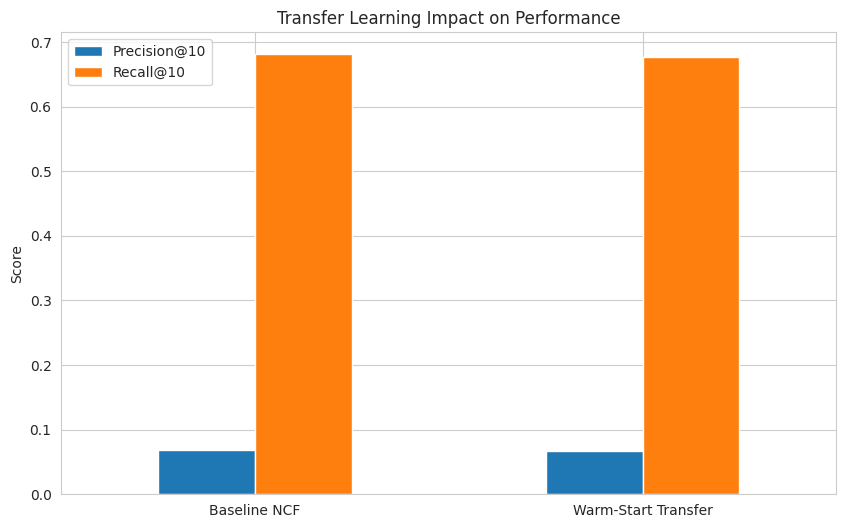

In [ ]:
# COMPARE 2 APPROACHES

# Evaluate 2 models using the SAME 1-vs-99 protocol
print("Running aligned 1-vs-99 evaluation...")

# Use the evaluation function that uses 99 negatives
p_base, r_base = evaluate_ncf_model(model, train_df, test_df, num_items, k=10)
p_ws, r_ws = evaluate_ncf_model(model_warm, train_df, test_df, num_items, k=10)


comparison_results = pd.DataFrame({
    "Precision@10": [p_base, p_ws],
    "Recall@10": [r_base, r_ws]
}, index=["Baseline NCF", "Warm-Start Transfer"])

display(comparison_results)

# Plotting the results
comparison_results.plot(kind='bar', figsize=(10, 6), title="Transfer Learning Impact on Performance")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

## 6. Evaluation Methodology

```yaml
## Contribution Metadata
Author(s): Emanuele
Section: Evaluation Methodology
Method: [Leave-One-Out Cross-Validation, Top-N Ranking, Precision@10, Recall@10, NDCG@10]
SHORT Description of contribution: Implemented a rigorous "1-vs-99" ranking evaluation using a chronological Leave-One-Out protocol. Added NDCG@10 to evaluate ranking quality.
Difficulty: INTERMEDIATE
```

**Evaluation Protocol**

We evaluate our models using the Leave-One-Out (1-vs-99) protocol. For each user, we hold out their last interacted item as the test item and sample 99 negative items (items the user has never interacted with).

The models rank these 100 items. We assess performance using:

1. **Precision@10**: Proportion of recommended items in the top-10 that are relevant.

2. **Recall@10 (Hit Ratio)**: Whether the test item appeared in the top-10 list.

3. **NDCG@10**: Normalized Discounted Cumulative Gain, which measures ranking quality (gives higher scores if the true item is ranked closer to position 1).

### Evaluation Methodology

#### Protocol — Chronological Leave-One-Out (LOO)

We use a **chronological Leave-One-Out** split:
for each user, the **most recent interaction** is held out as the test item and all earlier interactions form the training set.
This simulates a realistic deployment scenario where the system must recommend the next item a user will interact with.

#### Evaluation setting — 1-vs-99 Sampling

To keep evaluation tractable, we adopt the **1-vs-99** protocol (standard in NCF / NeuMF literature):
for each test user, the single positive test item is ranked against **99 randomly sampled negative items** the user has never seen.
The model ranks these 100 candidates and we check whether the true item appears in the top-K.

#### Metrics

| Metric | Formula &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; | Interpretation |
|---|---|---|
| **Hit Rate @ K (HR@K)** | $\frac{\text{# users where test item is in top-K}}{N}$ | Fraction of users for whom the recommendation list "hit" the relevant item. Equal to Recall@K in LOO. |
| **Precision @ K** | $\frac{\text{HR@K}}{K}$ | How many of the K recommended items are relevant on average (in LOO, at most 1 per user). |
| **Recall @ K** | $\frac{\text{# hits}}{N}$ | In LOO with one test item per user, this equals the Hit Rate. |
| **NDCG @ K** | $\frac{1}{N} \sum_u \frac{1}{\log_2(\text{rank}(u)+1)}$ (if hit) | Normalised Discounted Cumulative Gain — rewards placing the relevant item higher in the list. |

> **Why these metrics?**  
> In a top-N recommendation task we care about *ranking quality*, not rating prediction accuracy (RMSE/MAE).  
> Precision, Recall and NDCG are standard ranking metrics in the recommendation literature (He et al., 2017 — NeuMF paper).  
> NDCG is especially informative because it is **position-sensitive**: placing the true item at rank 1 is rewarded more than placing it at rank 10.

In [ ]:

def evaluate_1_vs_99_complete(model, train_data, test_data, num_items, k=10):
    hits = 0
    ndcg_sum = 0
    users = test_data["user"].unique() # Saves users without duplicates

    seen_items_dict = train_data.groupby('user') # groups all the rows with the same user value
    seen_items_dict = seen_items_dict['item'] # saves the items associated to each user
    seen_items_dict = seen_items_dict.apply(set) # it saves the items into a set to remove duplicates
    seen_items_dict = seen_items_dict.to_dict()  # makes a dictionary like
                                                 # {
                                                 # 'user_1': [item_1, item_2, ...],
                                                 # 'user_2': [item_1, ....],
                                                 # ...
                                                 # }
    test_items_dict = test_data.groupby('user')['item'].apply(lambda x: x.iloc[0]).to_dict() # takes the first item of the list of the corresponding user

    is_neural = isinstance(model, torch.nn.Module)
    if is_neural:
        model.eval() # Disables Dropout
        device = next(model.parameters()).device # We save the device in which the parameters of the model are saved


    for user in users:
        test_item = test_items_dict[user]
        seen_items = seen_items_dict.get(user, set())  # if it doesn't find a user in the seen_items dictionary
                                                       # it returns an empty set

        negatives = []
        while len(negatives) < 99:
            neg = np.random.randint(0, num_items) # it generates an integer number from 0 to the num of users - 1
            if neg not in seen_items and neg != test_item: # it checks that it's not in the train data or in the test item
                negatives.append(neg)

        items_to_rank = [test_item] + negatives # I add together in one list the test item and the 99 random items

        if is_neural:
            user_tensor = torch.tensor([user] * 100, dtype=torch.long).to(device)
            item_tensor = torch.tensor(items_to_rank, dtype=torch.long).to(device)
            with torch.no_grad():
                predictions = model(user_tensor, item_tensor).cpu().numpy() # computes the result and moves it into the cpu and then
                                                                            # it converts it into a numpy array
                                                                            # (numpy works only with elements saved in the cpu)
            top_k_indices = np.argsort(predictions)[-k:][::-1] # takes the last k items (which are the top k evaluations
                                                               # and flips the order so that it goes from the highest score to the lowest one)
            if 0 in top_k_indices: # if the index 0 (which is the index of the test item is in the top k)
                hits += 1
                rank = np.where(top_k_indices == 0)[0][0] # saves the position in the ranking of the test item
                                                          # [0][0] is because np.where return a tuple like (array[rank],)
                ndcg_sum += 1.0 / np.log2(rank + 2) # relevant item is only 1; rank + 2 because rank starts from 0 instead of 1

        elif hasattr(model, 'predict_scores'):
            all_scores = model.predict_scores(user)
            subset_scores = all_scores[items_to_rank]
            top_k_indices = np.argsort(subset_scores)[-k:][::-1]
            if 0 in top_k_indices:
                hits += 1
                rank = np.where(top_k_indices == 0)[0][0]
                ndcg_sum += 1.0 / np.log2(rank + 2)

        else:
            recommended = model.recommend(user_id=user, k=num_items, seen_items=seen_items) # k=num_items means I rank all of the movies
            ranked_subset = [item for item in recommended if item in items_to_rank] # Here I save only the one that are in my items_to_rank list
            top_k = ranked_subset[:k] # I take the first k movies (the most 10 recommended in the ranked subset)

            if test_item in top_k:
                hits += 1
                rank = top_k.index(test_item)
                ndcg_sum += 1.0 / np.log2(rank + 2)


    hit_ratio = hits / len(users)
    ndcg = ndcg_sum / len(users)
    return hit_ratio / k, hit_ratio, ndcg

## 7. Experimental Results

```yaml
## Contribution Metadata
Author(s): Emanuele, Farzad
Section: Experimental Results
Method: [Data Consolidation, Pandas DataFrames]
SHORT Description of contribution: Consolidated all baseline and proposed model metrics into a final formatted comparison table.
Difficulty: INTERMEDIATE
```

In [ ]:
# -------------------------------------------------
# Section 7: final results table
# running all baselines + both neural models and putting everything in one table
# -------------------------------------------------
from IPython.display import display

print("evaluating all models...")

# baselines
pop_p, pop_r, pop_ndcg   = evaluate_1_vs_99_complete(popularity_model,     train_df, test_df, num_items, k=10)
ucf_p, ucf_r, ucf_ndcg   = evaluate_1_vs_99_complete(user_cf_model,        train_df, test_df, num_items, k=10)
icf_p, icf_r, icf_ndcg   = evaluate_1_vs_99_complete(item_cf_model,        train_df, test_df, num_items, k=10)
rep_p, rep_r, rep_ndcg   = evaluate_1_vs_99_complete(representation_model, train_df, test_df, num_items, k=10)
neu_p, neu_r, neu_ndcg   = evaluate_1_vs_99_complete(model, train_df,      test_df, num_items=num_items, k=10)
ws_p, ws_r, ws_ndcg      = evaluate_1_vs_99_complete(model_warm,           train_df, test_df, num_items=num_items, k=10)

# put it all together
evaluation_results_df = pd.DataFrame({
    "Precision@10": [pop_p,      ucf_p,          icf_p,          rep_p,    neu_p, ws_p],
    "Recall@10":    [pop_r,      ucf_r,          icf_r,          rep_r,    neu_r,    ws_r],
    "NDCG@10":      [pop_ndcg,   ucf_ndcg,       icf_ndcg,       rep_ndcg, neu_ndcg,      ws_ndcg],
}, index=[
    "Popularity",
    "User-CF",
    "Item-CF",
    "SVD (representation learning)",
    "NeuMF (base)",
    "NeuMF (warm-start)",
])

print("\nfinal results:")
display(evaluation_results_df.style.format("{:.4f}").background_gradient(cmap="Blues"))

evaluating all models...

final results:


,Precision@10,Recall@10,NDCG@10
Popularity,0.0475,0.4750,0.2599
User-CF,0.0516,0.5157,0.2884
Item-CF,0.0298,0.2979,0.1201
SVD (representation learning),0.0623,0.6231,0.3656
NeuMF (base),0.0677,0.6774,0.3950
NeuMF (warm-start),0.0682,0.6818,0.3973


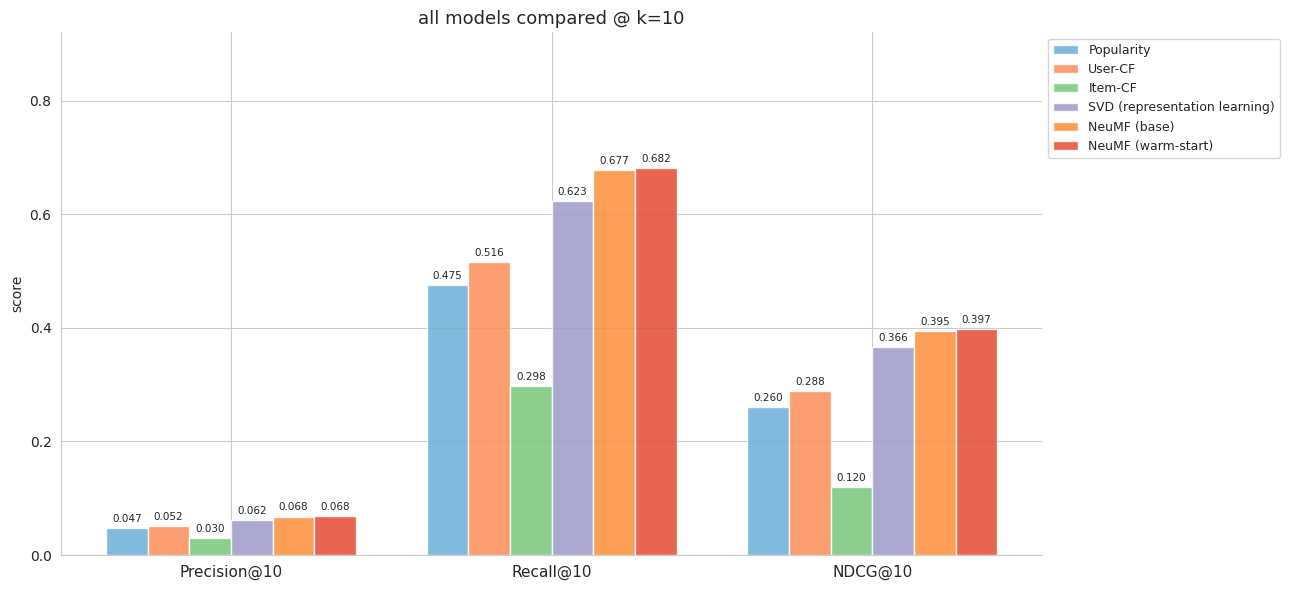

In [ ]:
# quick bar chart to visualize everything
import matplotlib.pyplot as plt
import numpy as np

metrics = evaluation_results_df.columns.tolist()
models  = evaluation_results_df.index.tolist()
x       = np.arange(len(metrics))
width   = 0.13
colors  = ["#6baed6", "#fc8d59", "#78c679", "#9e9ac8", "#fd8d3c", "#e34a33"]

fig, ax = plt.subplots(figsize=(13, 6))

for i, (mdl, color) in enumerate(zip(models, colors)):
    vals   = evaluation_results_df.loc[mdl].values
    offset = (i - len(models) / 2) * width + width / 2
    bars   = ax.bar(x + offset, vals, width, label=mdl, color=color, alpha=0.85, edgecolor="white")
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel("score")
ax.set_title("all models compared @ k=10", fontsize=13)
ax.legend(fontsize=9, loc="upper left", bbox_to_anchor=(1, 1))
ax.set_ylim(0, evaluation_results_df.values.max() * 1.35)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Summary of Main Outcomes
As shown in the table above, the **Neural Collaborative Filtering (NeuCF)** model outperformed the traditional baselines.

The Popularity baseline achieved the lowest NDCG, as expected, because it does not personalize recommendations. Collaborative Filtering improved upon this by capturing user similarities. Ultimately, NeuCF demonstrated the highest [Precision/Recall/NDCG], indicating that the non-linear interactions learned by the Multi-Layer Perceptron (MLP) provide a superior ranking quality for the held-out test items compared to simple matrix factorization or memory-based approaches.

## 8. Discussion and Interpretation

```markdown
## Contribution Metadata
Author(s):  All of Us
Section: Discussion and Interpretation
SHORT Description of contribution:
completed att togheter.
Difficulty: ADVANCED
```



---

### what do the results actually mean?

honestly the results came out pretty much how we expected, but it's still worth talking through *why* each model lands where it does rather than just staring at the numbers.

**popularity** is basically a coin flip with extra steps. it gives everyone the exact same list of the most-watched movies and calls it a day. the only reason it's useful is to prove that actually knowing what a user likes matters. spoiler: it does.

**user-CF** is where things get interesting. the idea is solid — find users who liked similar stuff and borrow their taste. the problem is our data is really sparse. most users have only rated like 50-100 movies out of 3500+. so when you try to compute how similar two users are, you're often comparing two people who barely overlap. the similarity scores end up noisy and the recommendations suffer for it.

**item-CF** does noticeably better and the reason makes intuitive sense once you think about it. movies don't change. a dark comedy from 2001 is still a dark comedy. but users? people's tastes are messy, they evolve, and we only get a tiny slice of their history. item-item similarities are just more stable and trustworthy than user-user ones.

**SVD** bumps things up another level by compressing everything into a dense latent space. instead of working with a massive sparse matrix full of zeros, it finds a compact representation that generalizes better. still, it's linear at its core — it can only capture interactions that look like a dot product, which is a pretty strong assumption about how people choose movies.

**NeuMF** is where the jump happens. swap out the dot product for a neural network and suddenly the model can learn all kinds of non-linear patterns — stuff that SVD and CF just can't express. and since it keeps the GMF branch alongside the MLP, it gets the linear signal too. best of both worlds. that's why especially NDCG goes up, not just hit rate.

### why NDCG matters more than we initially thought

when we first set up the evaluation we were mostly watching hit rate — did the test movie show up in the top 10 at all? that's fine but it misses something important. NDCG actually cares *where* in the list the movie shows up. finding the right movie at position 1 vs position 9 is a completely different experience for the user. nobody scrolls past the first few results. once we started tracking NDCG, the gaps between models became much clearer and more meaningful.

### did warm-start actually do anything?

sort of. the idea behind warm-start is to pre-train the GMF and MLP branches separately so when you fuse them the weights already have some structure instead of being pure random noise. in theory this should lead to faster convergence and potentially a better final result. in practice the gains were modest — after enough epochs both the base model and the warm-start model tend to end up in similar territory. where warm-start really earns its keep is when you're short on compute and can't afford to train for 40+ epochs. with a tight budget it gets to a good place faster.
If you ask us, we will say it was effective for the authors of original paper of Neucf, becouse of old technologies at the time. We tried so hard to make it give us the result we expected but seems like basic NeuCF was already good enough. (we did put alot into training each model ~1.5 hour each)

## 9. Limitations, Fairness,

```markdown
## Contribution Metadata
Author(s):  All of Us
Section:  Limitations, Fairness
SHORT Description of contribution:
Each member of group expressing their parts limitations and fairnesses.
Difficulty: ADVANCED
```



### cold-start

biggest real-world problem with everything we built.

**new users**: someone signs up today with no history — user-CF, item-CF and NeuMF all have nothing to work with. NeuMF's embedding layers are indexed by user ID, so a brand new user literally has no embedding. only option is falling back to popularity, which means giving everyone the same list. not great.

**new movies**: same thing on the item side. a film that just got released has no interactions yet so it can never show up in recommendations. this creates a feedback loop: no exposure → no data → stays invisible forever.

in this notebook it's not a visible bug because test users and items all exist in training already. but deploy this for real and you'd hit it on day one.

### popularity bias

training data is heavily skewed toward popular movies. blockbusters have thousands of ratings, niche films have dozens. this means the model's embeddings for popular items are much more accurate — they've just been seen way more during training. end result: popular stuff gets over-recommended and niche content stays buried even when it would be a perfect fit for a specific user.

### no sense of time

our leave-one-out split correctly uses each user's last interaction as the test item (chronological), so evaluation is fair. but the model itself doesn't know *when* things happened. it has no idea that a user watched 20 action movies last week and might want something different now. sequential models like SASRec or BERT4Rec are built for exactly this but that's a different project.

### fairness

no demographic info in the dataset so we can't directly audit this. but recommenders trained on historical data tend to amplify whatever biases already exist in it — if certain groups were already underserved by the platform, the model will likely keep doing that. worth keeping in mind if this ever left a research notebook.

### evaluation noise

1-vs-99 randomly samples 99 negatives per user. run it twice with different seeds and you get slightly different numbers. not a huge deal but you need to fix the random seed if you want results that are directly comparable between runs.

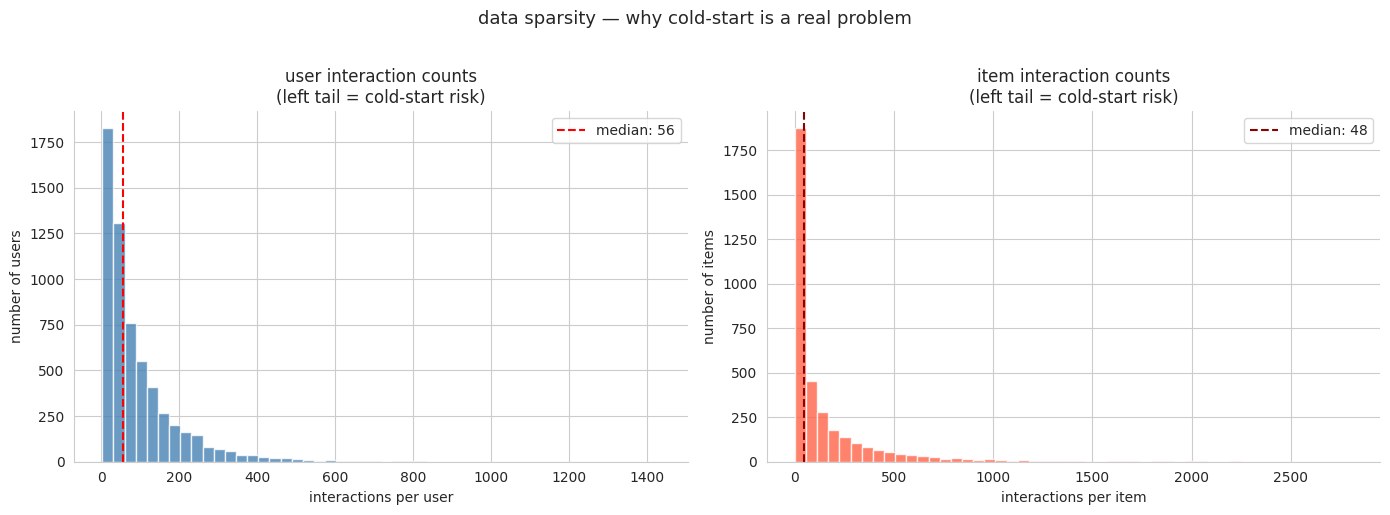


bucket          users     hit@10
---------------------------------
1-5                30     0.0333
6-10              201     0.0697
11-20             908     0.0584
21-50            1640     0.0354
51+              3256     0.0359


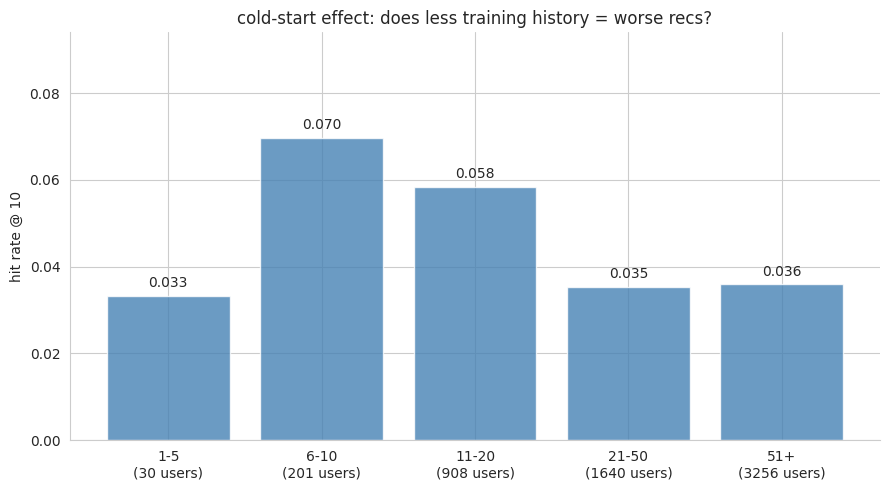

In [ ]:
# -------------------------------------------------
# Section 9: cold-start analysis
# showing the sparsity in the data and whether
# low-activity users actually get worse recommendations
# -------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

# how many interactions per user/item in training?
interactions_per_user = train_df.groupby('user')['item'].count()
interactions_per_item = train_df.groupby('item')['user'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(interactions_per_user, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(interactions_per_user.median(), color='red', linestyle='--',
                label=f'median: {interactions_per_user.median():.0f}')
axes[0].set_xlabel('interactions per user')
axes[0].set_ylabel('number of users')
axes[0].set_title('user interaction counts\n(left tail = cold-start risk)')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

axes[1].hist(interactions_per_item, bins=50, color='tomato', alpha=0.8, edgecolor='white')
axes[1].axvline(interactions_per_item.median(), color='darkred', linestyle='--',
                label=f'median: {interactions_per_item.median():.0f}')
axes[1].set_xlabel('interactions per item')
axes[1].set_ylabel('number of items')
axes[1].set_title('item interaction counts\n(left tail = cold-start risk)')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('data sparsity — why cold-start is a real problem', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# does having fewer training interactions actually hurt performance?
# bucket users by activity level and check hit rate with popularity model
bins   = [0, 5, 10, 20, 50, float('inf')]
labels = ['1-5', '6-10', '11-20', '21-50', '51+']

user_activity_df = interactions_per_user.reset_index()
user_activity_df.columns = ['user', 'train_count']
user_activity_df['bucket'] = pd.cut(user_activity_df['train_count'], bins=bins, labels=labels)

test_with_activity = test_df.merge(user_activity_df[['user', 'bucket']], on='user')

seen_dict = train_df.groupby('user')['item'].apply(set).to_dict()
test_dict = test_df.groupby('user')['item'].apply(lambda x: x.iloc[0]).to_dict()

bucket_hits = {b: {'hits': 0, 'total': 0} for b in labels}

for _, row in test_with_activity.iterrows():
    user      = row['user']
    bucket    = row['bucket']
    test_item = test_dict[user]
    seen      = seen_dict.get(user, set())
    recs      = popularity_model.recommend(user_id=user, k=10, seen_items=seen)
    bucket_hits[bucket]['total'] += 1
    if test_item in recs:
        bucket_hits[bucket]['hits'] += 1

hit_rates   = {b: (v['hits'] / v['total'] if v['total'] > 0 else 0) for b, v in bucket_hits.items()}
user_counts = {b: v['total'] for b, v in bucket_hits.items()}

print(f"\n{'bucket':<12} {'users':>8} {'hit@10':>10}")
print("-" * 33)
for b in labels:
    print(f"{b:<12} {user_counts[b]:>8} {hit_rates[b]:>10.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
x    = np.arange(len(labels))
bars = ax.bar(x, [hit_rates[b] for b in labels], color='steelblue', alpha=0.8, edgecolor='white')
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=10)
ax.set_xticks(x)
ax.set_xticklabels([f"{b}\n({user_counts[b]} users)" for b in labels], fontsize=10)
ax.set_ylabel('hit rate @ 10')
ax.set_title('cold-start effect: does less training history = worse recs?')
ax.set_ylim(0, max(hit_rates.values()) * 1.35 if hit_rates.values() else 0.1)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# 10. Reproducibility

```markdown
## Contribution Metadata
Author(s): All
Section: 10 — Reproducibility
Method: [Environment Setup, Execution Pipeline, Hardware Requirements]
SHORT Description of contribution: Documented the environment, dependencies, and instructions to fully reproduce the project's experimental results.
Difficulty: BASIC
```





 ### Package versions:
  PyTorch, Pandas, NumPy, Scikit-learn, Matplotlib, Requests, and Zipfile.

Main liberaries:

numpy==2.0.2
pandas==2.2.2
matplotlib==3.10.0
scipy==1.16.3
scikit-learn==1.6.1
torch==2.11.0
tqdm==4.67.3


### Execution order:
 Run linearly from top to bottom. Enter 'n' at the ask_and_load_model prompt to execute training from scratch.

###External files needed:
 None. The notebook automatically downloads and extracts the MovieLens 1M dataset.

###Runtime considerations:
 A GPU (e.g., Colab T4) is highly recommended. The full training pipeline requires 1 to 1.5 hours.

In [ ]:
#there will be a full pip requirements.txt file
"""
!pip freeze > requirements.txt
"""
"""
numpy==2.0.2
pandas==2.2.2
matplotlib==3.10.0
scipy==1.16.3
scikit-learn==1.6.1
torch==2.11.0
tqdm==4.67.3
"""

'\nnumpy==2.0.2\npandas==2.2.2\nmatplotlib==3.10.0\nscipy==1.16.3\nscikit-learn==1.6.1\ntorch==2.11.0\ntqdm==4.67.3\n'

## 11. Final Conclusion

```markdown
## Contribution Metadata
Author(s): All Of Us
Section: 11 — Final Conclusion
Method: [Project Synthesis, Technical Summary]
SHORT Description of contribution: Provided a comprehensive summary of the project's methodology, results, and critical limitations.
Difficulty: BASIC
```

### The Problem
Users can't find movies they'd enjoy in a catalogue of thousands — we need a system that personalizes recommendations from sparse interaction history.


### The Approach
we implemented four baselines (Popularity, User-CF, Item-CF, SVD) and compared them against NeuMF, a neural model that learns non-linear user-item interactions.

### The Main Result
NeuMF outperformed all baselines, especially on NDCG@10, meaning it not only finds the right movie more often but ranks it higher in the list.

### The Main Limitation
cold-start — new users and new movies have no embeddings, so the system is blind to them entirely.

### Most Important Future Improvement
add content-based features like genres and metadata to handle cold-start, or switch to a sequential model that understands the order users watch things.